# 🧠 Preprocessing and Analysis Pipeline for Functional Connectivity Matrices (rsfMRI) – HCB Cohort

This notebook implements a complete pipeline for the preprocessing and analysis of **functional connectivity matrices (rsfMRI)** from the HCB cohort. Each subject is associated with clinical information that allows stratification and statistical analysis.

---

## 🔧 Pipeline Overview

### 1. **Loading clinical and connectivity data**
- Functional rsfMRI matrices (76×76) are loaded for 178 subjects.
- Clinical metadata are loaded from a `.csv` file (`clinic_df`), containing variables such as:
  - `age`, `sex`
  - `controls_ms` (0 = control, 1 = patient)
  - `dd` (disease duration), `edss`, `mstype`
- Using a file of ROI labels (`mindboggle_ROIs.txt`), each connection is annotated with its **source and target region names**.
- Metadata includes pair indices, region names, and optional hemispheric information.

---

### 2. **Matrix vectorization**
- Only the upper triangle of each matrix is retained (due to symmetry), reducing dimensionality and avoiding redundancy.
- The result is a DataFrame of size (subjects × connections), with 2850 connections per subject.

---

### 3. **Detection of functionally absent connections**
- A diagnostic step detects connections that are **zero across all subjects**.
- These connections are visualized and **excluded from imputation and correction steps**, but are **restored after processing**.

---

### 4. **Covariate correction**
- Linear regression is applied **per connection** to remove effects of `age` and `sex`.
- The **residuals** of these models are used as corrected values.
- All-zero columns are skipped during fitting and restored afterward.

---

### 5. **Imputation of zero values**
One strategy is applied:

- **Linear regression**Predicts missing continuous values using linear regression and adds random Gaussian noise based on residuals.
- Structurally absent connections (all-zero columns) are **preserved** as zeros.


---

### 6. **Min-Max normalization**
- After covariate correction, values are standardized between 0 and 1 per connection using Mi-Max scaling.
- Preserves the same shape; all-zero columns remain unaffected.

---

### 7. **Batch harmonization with ComBat**
- The `SITE` variable (based on `redcap_event_name`) is used to define **batch acquisition**.
- `neuroHarmonize` (ComBat) is applied to remove inter-site variability.
- Batches with fewer than 3 subjects are excluded.
- All-zero columns are removed before harmonization and added back afterward.

---

### 8. **Masking of weak connections**
- Connections with values below `0.1` in **more than 60% of control subjects** are considered weak.
- These are **masked (set to zero)** rather than removed.
- Preserves comparability between subjects while suppressing noise.

---

### 9. **Visualization of Connectivity Matrices Before and After Corrections**

Group-wise mean connectivity matrices are computed and visualized for both controls and patients.  
Comparisons are shown at multiple stages of the pipeline:

- Before preprocessing (original raw matrices)
- After imputation, covariate correction, ComBat harmonization and mask weak connection (Median & KNN strategies)

These visualizations help assess how preprocessing steps affect overall brain connectivity patterns and highlight functional differences between groups.

---
### 10. **Demographic and clinical stratification**
- The pipeline enables stratified analyses based on:
  - **MS type** (`mstype`: RRMS, SPMS, PPMS)
  - **EDSS severity** (grouped into clinical ranges)
  - **Disease duration** (`dd`), binned into fine-grained categories
- Boxplots, matrices, and summary statistics are provided for each group.
 
---

### 11. **Export of results**
- Corrected matrices are saved as individual `.csv` files.
- Subject IDs are exported per subgroup (e.g., by `dd`, `edss_group`).
- Group summary statistics (age, EDSS, duration) are exported for reporting.

---

### 12. **Statistical Analysis Between Groups (Shapiro-Wilk, t-test, Mann-Whitney, Bonferroni)**

This step performs a connection-wise statistical comparison between control and MS patient groups using the vectorized connectivity data. Each connection (i.e., each column in the DataFrame) 
is tested for significant group differences.

---

## 📦 Ready for reuse:
This pipeline is ready to be replicated for:
- **Other connectivity layers**
- **Other cohorts**

Minimal changes are needed—just adjust the input matrix files and clinical metadata accordingly.


## Load Clinical Data

This function loads clinical data from a specified file path. It supports multiple formats: `.pkl`, `.csv`, `.parquet`, and `.feather`. The function returns a `pandas.DataFrame` and sets the patient ID as the index for easy access.

- **Function:** `load_dataframe(filepath)`
- **Input:** Path to the clinical data file.
- **Output:** Clinical data as a pandas DataFrame.
- **Supported formats:** Pickle, CSV, Parquet, Feather.

Example usage:
```python
clinic_df = load_dataframe("CLINIC_HCB.pkl")
clinic_df.set_index('id', inplace=True)


In [1]:
# Import necessary libraries
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
#from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import os
import glob
from neuroHarmonize import harmonizationLearn
from scipy.stats import ttest_ind, chi2_contingency#, shapiro, mannwhitneyu, spearmanr, pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
#import networkx as nx
#from statsmodels.stats.multitest import multipletests
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.model_selection import cross_val_score


# === 1.A Load clinical data ===
def load_dataframe(filepath):
    """
    Load clinical data from file, detecting format.

    Args:
        filepath (str or Path): Path to the clinical data file.

    Returns:
        DataFrame: Loaded clinical data.
    """
    if str(filepath).endswith('.pkl'):
        df = pd.read_pickle(filepath)
    elif str(filepath).endswith('.csv'):
        df = pd.read_csv(filepath)
    elif str(filepath).endswith('.parquet'):
        df = pd.read_parquet(filepath)
    elif str(filepath).endswith('.feather'):
        df = pd.read_feather(filepath)
    else:
        raise ValueError("❌ Unsupported file format.")
    
    print(f"✅ Clinical data loaded successfully from {filepath.name}") 
    return df

# Data to be changed by each situation 
# ==============================================================================================================
################################################################################################################
route = Path('F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB') 
clinic_df = load_dataframe(route / 'CLINIC_HCB_ck.csv')
clinic_df.set_index('id', inplace=True)
################################################################################################################
clinic_df.head()

✅ Clinical data loaded successfully from CLINIC_HCB_ck.csv


,Unnamed: 0,redcap_event_name,controls_ms,dob,msonset,nrldate,age,sex,dd,mstype,...,edss,uGMSSS,oGMSSS,sdmt,sdmtz,pasat,zpasat,FA,GM,RF
id,,,,,,,,,,,,,,,,,,,,,
002MSVIS,0,year3_arm_1,1,1963-09-04,1993-01-10,2015-03-16,51.53,1,22.18,1,...,7.5,8.36,8.103,NaN,NaN,55.0,0.2857,1,1,1
003MSVIS,1,year5_arm_1,1,1959-01-18,2007-07-15,2017-02-08,58.06,0,9.57,2,...,6.0,7.71,7.385,38.0,-0.7770,25.0,-2.6600,1,1,1
004MSVIS,2,year5_arm_1,1,1956-09-16,2010-09-15,2017-06-29,60.78,1,6.79,0,...,3.0,5.46,4.966,61.0,1.6250,58.0,0.7142,1,1,1
005MSVIS,3,year5_arm_1,1,1978-02-01,2007-08-01,2016-01-13,37.95,0,8.45,0,...,1.5,2.41,1.922,37.0,-0.5384,NaN,NaN,1,1,1
010MSVIS,4,year5_arm_1,1,1964-02-13,2007-09-15,2016-10-04,52.64,0,9.05,0,...,2.0,3.13,2.649,NaN,NaN,40.0,-0.5000,1,1,1


## Load Functional Connectivity (rsfMRI) Matrices

This function loads all Functional Connectivity (rsfMRI) connectivity matrices from a specified folder. It reads `.csv` files, converts them to NumPy arrays, and stores them in a dictionary using subject IDs extracted from the filenames.

- **Function:** `load_matrices_from_folder(folder_path)`
- **Input:** Path to the folder containing `.csv` rsfMRI matrices.
- **Output:** Dictionary of matrices `{subject_id: matrix}`

Each matrix is assumed to be stored in a file named like `"123456_rsfMRI_rsfmrictor.csv"`, and is loaded into memory as a NumPy array.

Example usage:
```python
rsfmri_matrices = load_matrices_from_folder("path/to/folder")


✅ Loaded 170 rsfMRI matrices from 'F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/rsfmri_networks'
dict_keys(['002MSVIS', '003MSVIS', '004MSVIS', '005MSVIS', '010MSVIS', '011MSVIS', '012MSVIS', '017MSVIS', '018MSVIS', '019MSVIS', '021MSVIS', '022MSVIS', '027MSVIS', '030MSVIS', '031MSVIS', '032MSVIS', '033MSVIS', '035MSVIS', '036MSVIS', '038MSVIS', '039MSVIS', '040MSVIS', '041MSVIS', '042MSVIS', '043MSVIS', '044MSVIS', '046MSVIS', '047MSVIS', '048MSVIS', '050MSVIS', '053MSVIS', '054MSVIS', '055MSVIS', '056MSVIS', '058MSVIS', '059MSVIS', '061MSVIS', '062MSVIS', '063MSVIS', '064MSVIS', '065MSVIS', '066MSVIS', '067MSVIS', '070MSVIS', '071MSVIS', '072MSVIS', '073MSVIS', '074MSVIS', '075MSVIS', '076MSVIS', '077MSVIS', '078MSVIS', '079MSVIS', '080MSVIS', '082MSVIS', '083MSVIS', '084MSVIS', '086MSVIS', '087MSVIS', '088MSVIS', '089MSVIS', '090MSVIS', '091MSVIS', '092MSVIS', '094MSVIS', '095MSVIS', '096MSVIS', '097MSVIS', '098MSVIS', '099MSVIS',

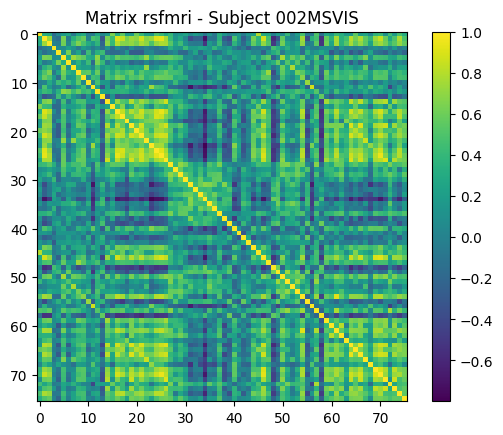

In [2]:
# === 1B. Load rsfMRI matrices ===
def load_matrices_from_folder(folder_path):
    """
    Load all rsfMRI connectivity matrices from a folder.
    
    Args:
        folder_path (str): Path to the folder containing the matrices.

    Returns:
        dict: {subject_id: connectivity matrix}
    """
    matrices = {}
    file_list = glob.glob(os.path.join(folder_path, "*.csv"))
    # Extract subject IDs from filenames ("123456_rsfMRI_rsfmrictor.csv" → "123456")
    for file in file_list:
        subj_id = os.path.basename(file).replace('_r_matrix.csv', '')
        # Convert DataFrame to array NumPy
        matrix = pd.read_csv(file, header=None).values
        # Save matrix in the dictionary (by id)
        matrices[subj_id] = matrix
        
    print(f"✅ Loaded {len(matrices)} rsfMRI matrices from '{folder_path}'")    
    return matrices
    # "123456": array([[...], [...], ...]),

# Data to be changed by each situation 
# ==============================================================================================================
################################################################################################################
folder_path = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/rsfmri_networks"
################################################################################################################
rsfmri_matrices = load_matrices_from_folder(folder_path)
print(rsfmri_matrices.keys()) # Check the keys of the dictionary (subject IDs)
print(rsfmri_matrices['002MSVIS'])

# Plot the FA matrix for a specific subject
plt.imshow(rsfmri_matrices['002MSVIS'], cmap='viridis')
plt.title('Matrix rsfmri - Subject 002MSVIS')
plt.colorbar()
plt.show()

## Load ROI Labels

This code snippet loads region-of-interest (ROI) labels from a text file and stores them in a dictionary. Each label is associated with a numerical index (adjusted to be zero-based for Python compatibility).

- **Input file:** `mindboggle_ROIs.txt`
- **Output:** Dictionary `{index: region_name}`

Lines that are empty or start with `[` are ignored. The index is adjusted by `-1` to match Python's zero-based indexing.

Example dictionary entry:
```python
{
    0: "Left-Thalamus",
    1: "Left-Caudate",
    ...
}


In [3]:
# === 1C. Etiquets load from ROI ===
region_labels = {}
with open("F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/mindboggle_ROIs.txt") as f:
    for line in f:
        if line.strip().startswith('[') or not line.strip():
            continue
        idx, name = line.strip().split(maxsplit=1)
        region_labels[int(idx) - 1] = name
region_labels

{0: 'ctx-lh-caudalanteriorcingulate',
 1: 'ctx-lh-caudalmiddlefrontal',
 2: 'ctx-lh-cuneus',
 3: 'ctx-lh-entorhinal',
 4: 'ctx-lh-fusiform',
 5: 'ctx-lh-inferiorparietal',
 6: 'ctx-lh-inferiortemporal',
 7: 'ctx-lh-isthmuscingulate',
 8: 'ctx-lh-lateraloccipital',
 9: 'ctx-lh-lateralorbitofrontal',
 10: 'ctx-lh-lingual',
 11: 'ctx-lh-medialorbitofrontal',
 12: 'ctx-lh-middletemporal',
 13: 'ctx-lh-parahippocampal',
 14: 'ctx-lh-paracentral',
 15: 'ctx-lh-parsopercularis',
 16: 'ctx-lh-parsorbitalis',
 17: 'ctx-lh-parstriangularis',
 18: 'ctx-lh-pericalcarine',
 19: 'ctx-lh-postcentral',
 20: 'ctx-lh-posteriorcingulate',
 21: 'ctx-lh-precentral',
 22: 'ctx-lh-precuneus',
 23: 'ctx-lh-rostralanteriorcingulate',
 24: 'ctx-lh-rostralmiddlefrontal',
 25: 'ctx-lh-superiorfrontal',
 26: 'ctx-lh-superiorparietal',
 27: 'ctx-lh-superiortemporal',
 28: 'ctx-lh-supramarginal',
 29: 'ctx-lh-transversetemporal',
 30: 'ctx-lh-insula',
 31: 'Left-Thalamus-Proper',
 32: 'Left-Caudate',
 33: 'Left-Puta

## Vectorize Connectivity Matrices

This function vectorizes the upper triangle (excluding the diagonal) of each subject's connectivity matrix and stores the result in a DataFrame. Each row corresponds to a subject, and each column to a unique brain connection.

Additionally, if region labels are provided, it generates a metadata table describing each connection.

- **Function:** `vectorize_matrices(matrices, region_labels)`
- **Inputs:**
  - `matrices`: Dictionary `{subject_id: connectivity_matrix}`
  - `region_labels`: Dictionary `{index: region_name}` (optional)
- **Outputs:**
  - `df_vectors`: DataFrame (subjects × connections)
  - `triu_idx`: Tuple of upper triangle indices
  - `connection_metadata`: DataFrame with connection details (`i`, `j`, `Region_i`, `Region_j`)

Example output:
```python
df_vectors.shape = (N_subjects, N_connections)


In [4]:
# === 2. Vectorization ===
def vectorize_matrices(matrices, region_labels):
    """
    Vectorize the upper triangle (k=1) of each connectivity matrix.
    
    Args:
        matrices (dict): {subject_id: connectivity matrix}
        region_labels (dict): Optional. Mapping from region index to name.

    Returns:
        df_vectors (DataFrame): Vectorized matrices (subjects x connections)
        triu_idx (tuple): Indices of upper triangle used.
        connection_metadata (DataFrame): Info per connection (i, j, Region_i, Region_j)
 
    """
    vectors = {}
    for subj, matrix in matrices.items():
        # Return coordenates (indexes) from the upper triangular (not including the diagonal)
        # [[0, a, b],
        #  [a, 0, c],
        #  [b, c, 0]] -> Returns [a, b, c]
        triu_idx = np.triu_indices_from(matrix, k=1)
        vectors[subj] = matrix[triu_idx]
    
    df_vectors = pd.DataFrame.from_dict(vectors, orient='index')
    
    # Get matrix size from the first element
    example_shape = next(iter(matrices.values())).shape

    print(f"✅ Vectorization complete: {df_vectors.shape[0]} subjects, {df_vectors.shape[1]} connections per subject (original matrix size: {example_shape[0]}x{example_shape[1]})")
    
    # === Build connection metadata (if labels provided) ===
    if region_labels is not None:
        data = []
        for col in range(len(triu_idx[0])):
            i = triu_idx[0][col]
            j = triu_idx[1][col]
            name_i = region_labels.get(i, f"Region{i}")
            name_j = region_labels.get(j, f"Region{j}")
            data.append((col, i, j, name_i, name_j))
        connection_metadata = pd.DataFrame(data, columns=["Col_Index", "i", "j", "Region_i", "Region_j"])
    else:
        connection_metadata = None

    return df_vectors, triu_idx, connection_metadata
    #return df_vectors, triu_idx

rsfmri_vectors, triu_idx, connection_metadata = vectorize_matrices(rsfmri_matrices,region_labels=region_labels)
print(rsfmri_vectors.head()) # Check the first rows of the DataFrame
print(triu_idx) # Check the indexes of the upper triangular matrixc
connection_metadata # Check the connection metadata (if labels provided)

✅ Vectorization complete: 170 subjects, 2850 connections per subject (original matrix size: 76x76)
              0         1         2         3         4         5     \
002MSVIS  0.322330  0.291303 -0.164336  0.046820  0.183494  0.256288   
003MSVIS  0.022460  0.166492  0.061316  0.193466 -0.144947  0.049071   
004MSVIS  0.703222 -0.227005  0.575081  0.579168  0.237380  0.300360   
005MSVIS  0.398313  0.198188  0.346499 -0.034467  0.302836  0.396598   
010MSVIS  0.087240 -0.042135  0.139666 -0.234097  0.042509  0.388598   

              6         7         8         9     ...      2840      2841  \
002MSVIS -0.054844  0.244313  0.308048 -0.033437  ...  0.120850  0.861632   
003MSVIS  0.086764  0.127055  0.258640  0.206327  ...  0.185334  0.678726   
004MSVIS  0.546444  0.240103 -0.354785  0.600903  ...  0.515752  0.627264   
005MSVIS  0.151663  0.328032  0.449965  0.103640  ...  0.434069  0.705460   
010MSVIS  0.417677  0.062563  0.030597 -0.002318  ...  0.279513  0.672975   

     

,Col_Index,i,j,Region_i,Region_j
0,0,0,1,ctx-lh-caudalanteriorcingulate,ctx-lh-caudalmiddlefrontal
1,1,0,2,ctx-lh-caudalanteriorcingulate,ctx-lh-cuneus
2,2,0,3,ctx-lh-caudalanteriorcingulate,ctx-lh-entorhinal
3,3,0,4,ctx-lh-caudalanteriorcingulate,ctx-lh-fusiform
4,4,0,5,ctx-lh-caudalanteriorcingulate,ctx-lh-inferiorparietal
...,...,...,...,...,...
2845,2845,72,74,ctx-rh-superiortemporal,ctx-rh-transversetemporal
2846,2846,72,75,ctx-rh-superiortemporal,ctx-rh-insula
2847,2847,73,74,ctx-rh-supramarginal,ctx-rh-transversetemporal
2848,2848,73,75,ctx-rh-supramarginal,ctx-rh-insula


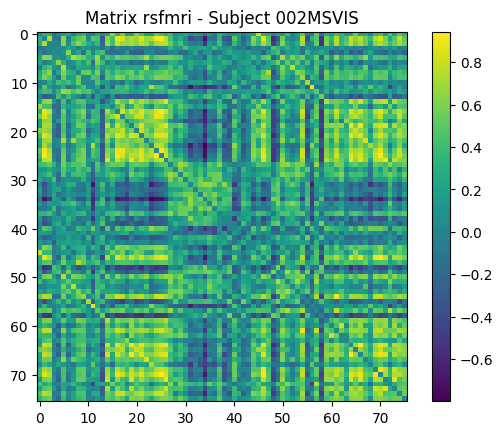

In [5]:
# Rebuild the original matrix from the vector
# 1. Get the first vector
first_subject_id = rsfmri_vectors.index[0]
first_vector = rsfmri_vectors.loc[first_subject_id].values

# 2. Get the size of the original matrix (e.g., 76x76)  
matrix_size = next(iter(rsfmri_matrices.values())).shape[0]

# 3. Create an empty matrix
reconstructed_matrix = np.zeros((matrix_size, matrix_size))

# 4. Insert the values from the vector into the upper triangle  
i_indices, j_indices = triu_idx

# 5. Copy symmetrically to the lower triangle
reconstructed_matrix[i_indices, j_indices] = first_vector

# 6. Plot the matrix    
reconstructed_matrix[j_indices, i_indices] = first_vector
plt.imshow(reconstructed_matrix, cmap='viridis')
plt.title(f"Matrix rsfmri - Subject {first_subject_id}")
plt.colorbar()
plt.show()

## Detect and Visualize All-Zero Connections

This function identifies brain connections (i.e., edges in the connectivity matrix) that are zero across all subjects. These connections are likely absent or invalid across the dataset. The function also visualizes these connections in matrix form and prints a summary table.

- **Function:** `plot_zero_connections(df_vectors, triu_idx)`
- **Inputs:**
  - `df_vectors`: DataFrame with vectorized connectivity matrices.
  - `triu_idx`: Indices of upper triangle used during vectorization.
- **Outputs:**
  - `zero_conn_indices`: List of `(i, j)` pairs with all-zero values.

**Features:**
- Prints the number and indices of all-zero connections.
- Displays two heatmaps:
  1. Full view of all-zero connections across all regions.
  2. Zoomed-in view (region indices 0–80).
- Useful for quality control and optional filtering/imputation.

Example usage:
```python
zero_conns = plot_zero_connections(rsfmri_vectors, triu_idx)


⚠️ Number of connections always zero: 0


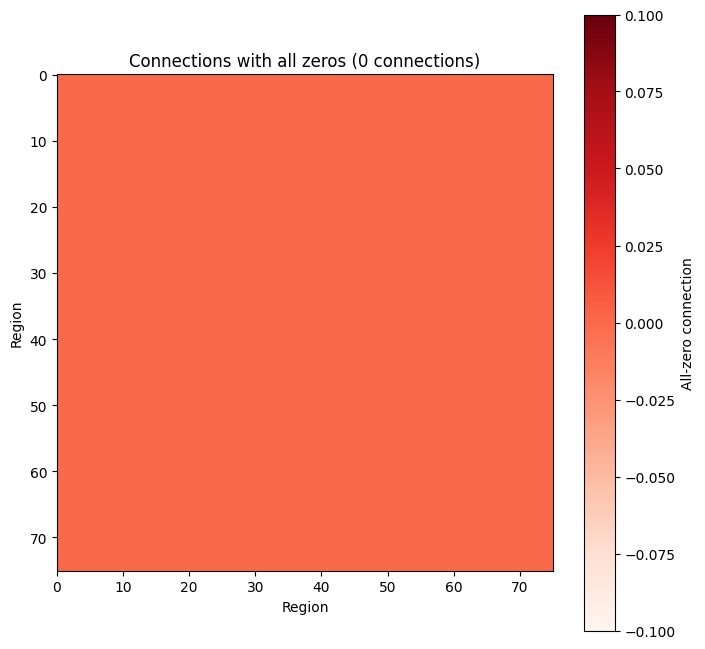

✅ No connections were found with all-zero values across subjects
✅ Detection and visualization of all-zero connections completed.



In [6]:
# === 3. Function to visualize connections with all zeros (raw data) ===
def plot_zero_connections(df_vectors, triu_idx):
    """
    Detect and visualize connections (i, j) that are zero across all subjects.
    Also prints a table with these connections.

    Args:
        df_vectors (DataFrame): Vectorized connectivity matrices.
        triu_idx (tuple): Indices of upper triangle used in vectorization.

    Returns:
        zero_conn_indices (list): List of (i, j) pairs with all zeros.
    """
    # Detect connections (columns) where all subjects have zero
    zero_cols = df_vectors.columns[(df_vectors == 0).all()]
    print(f"⚠️ Number of connections always zero: {len(zero_cols)}")

    # Map back to (i, j) pairs
    zero_conn_indices = [(triu_idx[0][col], triu_idx[1][col]) for col in zero_cols]

    # === Mask for visualization for all zero ===
    n = len(triu_idx[0]) + 1
    mask = np.zeros((n, n))
    for i, j in zero_conn_indices:
        mask[i, j] = 1
        mask[j, i] = 1  # Symmetric
    
    plt.figure(figsize=(8, 8))  # Size of the figure
    plt.imshow(mask, cmap="Reds")
    plt.xlim(0, 75)
    plt.ylim(75, 0)
    plt.title(f"Connections with all zeros ({len(zero_conn_indices)} connections)")
    plt.xlabel("Region")
    plt.ylabel("Region")  
    plt.colorbar(label="All-zero connection")
    plt.show() 
    
    # === Summary able ===
    if zero_conn_indices:
        df_zero = pd.DataFrame(zero_conn_indices, columns=['Region_i', 'Region_j'])
        print("\n🔍 Number of connections always zero:")
        print(df_zero)
    else:
        print("✅ No connections were found with all-zero values across subjects")

    print("✅ Detection and visualization of all-zero connections completed.\n")
    return zero_conn_indices

# Visualize connections "always zero" BEFORE pre-processing 
zero_conns = plot_zero_connections(rsfmri_vectors, triu_idx)


## Detect and Visualize Problematic Brain Connections

This module detects brain connections that are either fully zero or sparsely connected (>60% zeros) across subjects, analyzing Controls and EM groups separately.

### Main Functions:

- `plot_sparse_connections(df_vectors, triu_idx, clinic_df, threshold=0.6)`
  - Identifies and visualizes:
    - All-zero connections in Controls.
    - All-zero connections in EM patients.
    - Sparse connections (>60% zeros) in Controls.
    - Sparse connections (>60% zeros) in EM patients.
  - Outputs a dictionary of `(i, j)` region pairs per category with individual heatmaps.

- `plot_combined_problematic_connections(mapped, triu_idx)`
  - Combines all problematic connections into a single global heatmap.
  - Useful for a quick overview before filtering.

### Highlights:
- Group-specific analysis (Controls vs EM).
- Detects both full-zero and sparse connections.
- Compatible with FA, GM, and rsfMRI layers.
- Helps in quality control before machine learning or graph analyses.

**Example usage:**
```python
mapped = plot_sparse_connections(fa_vectors, triu_idx, clinic_df)
all_problematic = plot_combined_problematic_connections(mapped, triu_idx)


In [7]:
# === 3.2 Function to visualize connections with all zeros + 0.6 (EM vs Controls - Distinction) ===
def plot_sparse_connections(df_vectors, triu_idx, clinic_df, threshold=0.6):
    """
    Detect and visualize sparse connections based on group (Controls vs EM).
    
    Args:
        df_vectors (DataFrame): Vectorized connectivity matrices (subjects x connections).
        triu_idx (tuple): Indices of upper triangle used in vectorization.
        clinic_df (DataFrame): Clinical data with 'controls_ms' column.
        threshold (float): Threshold for defining sparse connections (>60% zeros).
    
    Returns:
        dict: Dictionary with lists of problematic (i, j) connections by category.
    """
    print("🔎 Starting sparse connection analysis...\n")
    
    controls = clinic_df[clinic_df['controls_ms'] == 0].index
    patients = clinic_df[clinic_df['controls_ms'] == 1].index
    
    # --- Detect problems
    zero_cols_controls = df_vectors.loc[controls].columns[(df_vectors.loc[controls] == 0).all()]
    zero_cols_patients = df_vectors.loc[patients].columns[(df_vectors.loc[patients] == 0).all()]

    zero_pct_controls = (df_vectors.loc[controls] == 0).sum() / len(controls)
    zero_pct_patients = (df_vectors.loc[patients] == 0).sum() / len(patients)

    sparse_controls = zero_pct_controls[zero_pct_controls > threshold].index
    sparse_patients = zero_pct_patients[zero_pct_patients > threshold].index

    # --- Map back to (i, j) coordinates
    def map_back(cols):
        return [(triu_idx[0][col], triu_idx[1][col]) for col in cols]

    mapped = {
        "all_zero_controls": map_back(zero_cols_controls),
        "all_zero_patients": map_back(zero_cols_patients),
        "sparse_controls": map_back(sparse_controls),
        "sparse_patients": map_back(sparse_patients)
    }
    
    # --- Visualizations
    n = len(triu_idx[0]) + 1  # Assuming (i,j) from triu of size n
    
    for key, conn_list in mapped.items():
        if not conn_list:
            print(f"✅ No connections found for {key.replace('_', ' ')}.\n")
            continue
        
        print(f"⚠️ {len(conn_list)} connections found for {key.replace('_', ' ')}.")
        
        # Create mask
        mask = np.zeros((n, n))
        for i, j in conn_list:
            mask[i, j] = 1
            mask[j, i] = 1  # Symmetrize
        
        plt.figure(figsize=(8, 8))
        plt.imshow(mask, cmap="Reds")
        plt.xlim(0, 75)
        plt.ylim(75, 0)
        plt.title(f"{key.replace('_', ' ').title()} ({len(conn_list)} connections)")
        plt.xlabel("Region")
        plt.ylabel("Region")
        plt.colorbar(label="Problematic connection")
        plt.show()

    print("✅ Sparse connection visualization completed.\n")
    
    return mapped

# === Example call
mapped_connections = plot_sparse_connections(rsfmri_vectors, triu_idx, clinic_df)
#plot_sparse_connections(rsfmri_vectors, triu_idx, clinic_df)

🔎 Starting sparse connection analysis...

✅ No connections found for all zero controls.

✅ No connections found for all zero patients.

✅ No connections found for sparse controls.

✅ No connections found for sparse patients.

✅ Sparse connection visualization completed.



⚠️ Total problematic connections (to filter out): 0


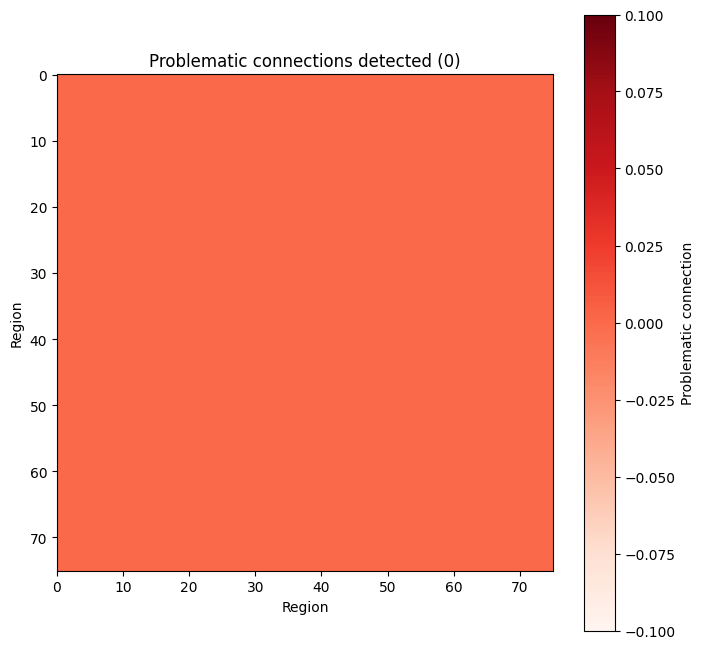

✅ No problematic connections detected.
✅ Detection and visualization completed.



In [8]:
# === 3.3 Function to visualize all problematic connections zeros + 0.6 (EM & Controls - No Distinction) ===
def plot_problematic_connections(df_vectors, clinic_df, triu_idx, threshold=0.6):
    """
    Visualize and summarize connections with:
    - All zeros in controls or patients
    - More than `threshold` zeros in controls or patients

    Args:
        df_vectors (DataFrame): Vectorized connectivity matrices.
        clinic_df (DataFrame): Clinical info with 'controls_ms' column (0=Control, 1=EM).
        triu_idx (tuple): Indices of upper triangle used in vectorization.
        threshold (float): Proportion threshold for considering a connection unreliable.
        
    Returns:
        problematic_conn_indices (list): List of (i, j) pairs marked as problematic.
    """
    # Separate controls and patients
    controls = clinic_df[clinic_df['controls_ms'] == 0].index
    patients = clinic_df[clinic_df['controls_ms'] == 1].index

    # Detect columns problematic in controls
    zero_controls = (df_vectors.loc[controls] == 0).all()
    sparse_controls = (df_vectors.loc[controls] == 0).mean() > threshold

    # Detect columns problematic in patients
    zero_patients = (df_vectors.loc[patients] == 0).all()
    sparse_patients = (df_vectors.loc[patients] == 0).mean() > threshold

    # Columns to drop
    cols_to_drop = df_vectors.columns[
        zero_controls | sparse_controls | zero_patients | sparse_patients
    ]

    print(f"⚠️ Total problematic connections (to filter out): {len(cols_to_drop)}")

    # Map back to (i, j) pairs
    problematic_conn_indices = [(triu_idx[0][col], triu_idx[1][col]) for col in cols_to_drop]

    # === Visualization Mask ===
    n = len(triu_idx[0]) + 1  # Number of regions
    mask = np.zeros((n, n))
    for i, j in problematic_conn_indices:
        mask[i, j] = 1
        mask[j, i] = 1  # Symmetric

    # Plot full mask
    plt.figure(figsize=(8, 8))
    plt.imshow(mask, cmap="Reds")
    plt.xlim(0, 75)
    plt.ylim(75, 0)
    plt.title(f"Problematic connections detected ({len(problematic_conn_indices)})")
    plt.xlabel("Region")
    plt.ylabel("Region")
    plt.colorbar(label="Problematic connection")
    plt.show()

    # Plot zoomed in (0-80)
    #plt.figure(figsize=(8, 8))
    #plt.imshow(mask, cmap="Reds")
    #plt.xlim(0, 75)
    #plt.ylim(75, 0)
    #plt.title("Zoom into Region 0-80 (problematic connections)")
    #plt.xlabel("Region")
    #plt.ylabel("Region")
    #plt.colorbar(label="Problematic connection")
    #plt.show()

    # === Summary table ===
    if problematic_conn_indices:
        df_problematic = pd.DataFrame(problematic_conn_indices, columns=['Region_i', 'Region_j'])
        print("\n🔍 Summary of problematic connections:")
        print(df_problematic)
    else:
        print("✅ No problematic connections detected.")

    print("✅ Detection and visualization completed.\n")
    return problematic_conn_indices


problematic_conns = plot_problematic_connections(rsfmri_vectors, clinic_df, triu_idx)
#plot_problematic_connections(rsfmri_vectors, clinic_df, triu_idx)

In [9]:
# =========================================================
# Convert problematic (i, j) pairs to column indices
# =========================================================

def get_cols_to_preserve_from_problematic(problematic_conns, triu_idx):
    """
    Given (i,j) indices of problematic connections, find the corresponding column indices in the vectorized matrix.

    Args:
        problematic_conn_indices (list): List of (i, j) tuples.
        triu_idx (tuple): Output of np.triu_indices used in vectorization.

    Returns:
        list: Column indices to preserve.
    """
    mapping = {(i, j): idx for idx, (i, j) in enumerate(zip(triu_idx[0], triu_idx[1]))}
    cols = []
    for conn in problematic_conns:
        if conn in mapping:
            cols.append(mapping[conn])
        else:
            # Maybe (j, i) if the order was flipped
            conn_flipped = (conn[1], conn[0])
            if conn_flipped in mapping:
                cols.append(mapping[conn_flipped])
    return cols

# Obtain the column indices to preserve from the problematic connections
cols_to_preserve = get_cols_to_preserve_from_problematic(problematic_conns, triu_idx)
print(f"🔎 Total columns to preserve (problematic): {len(cols_to_preserve)}")
cols_to_preserve[0:10]  # Show first 10 indices

🔎 Total columns to preserve (problematic): 0


[]

## Covariate Correction (Linear Regression)

This function corrects each brain connection (column) in the vectorized connectivity matrix for covariates (e.g., age, sex) using linear regression. It returns the residuals of the regression, effectively removing the effect of the specified covariates. Columns that are entirely zero across all subjects are preserved and not corrected.

- **Function:** `correct_vectors_covariates(df_vectors, clinic_df, covariates=['age', 'sex'])`
- **Inputs:**
  - `df_vectors`: Vectorized connectivity matrix (`subjects × connections`)
  - `clinic_df`: Clinical DataFrame containing covariate information
  - `covariates`: List of covariates to correct for (dersfmriult: `['age', 'sex']`)
- **Output:** DataFrame of covariate-corrected values (same shape as input)

**Key Features:**
- Automatically aligns subject indices between connectivity and clinical data.
- Skips columns that are all-zero.
- Applies linear regression to each connection individually.
- Replaces each value with its residual (i.e., covariate-adjusted value).

Example usage:
```python
rsfmri_vectors_median_corrected = correct_vectors_covariates(rsfmri_vectors_median, clinic_df)


In [10]:
# === 4. Covariate correction ===

def correct_vectors_covariates(df_vectors, clinic_df, covariates=['age', 'sex'], verbose=True):
    """
    Correct each connection by covariates (e.g., age and sex) using linear regression.
    Preserves columns that are all zeros.

    Args:
        df_vectors (DataFrame): Vectorized connectivity matrices (subjects x connections).
        clinic_df (DataFrame): Clinical data.
        covariates (list): List of covariate names.
        verbose (bool): Whether to print info messages.

    Returns:
        DataFrame: Covariate-corrected matrix (same shape as input).
    """
    # Subjects in common between clinical and connectivity data
    common_subjects = df_vectors.index.intersection(clinic_df.index)

    # Select covariates and drop rows with missing values
    df_covars = clinic_df.loc[common_subjects, covariates].dropna()

    # Align matrix to subjects with valid covariates
    df_vectors = df_vectors.loc[df_covars.index]

    if verbose:
        print(f"🔍 Subjects with corrected data: {len(df_vectors)}")
        print(f"🔍 Covariates shape: {df_covars.shape}")
        print(f"🔍 Common subject IDs: {list(df_covars.index)}")

    # Detect all-zero columns (to skip them)
    zero_cols = df_vectors.columns[(df_vectors == 0).all()]
    if verbose:
        print(f"⚠️ Skipping covariate correction for {len(zero_cols)} all-zero columns.")

    # Work only on valid columns
    df_tmp = df_vectors.drop(columns=zero_cols)

    # === Check for NaNs before regression ===
    nan_check_cols = df_tmp.columns[df_tmp.isna().any()]
    if len(nan_check_cols) > 0:
        print(f"⚠️ Detected {len(nan_check_cols)} columns with NaN values BEFORE regression.")
        print("🔍 Columns with NaNs:", list(nan_check_cols[:10]), "..." if len(nan_check_cols) > 10 else "")    
    
    # Initialize corrected matrix with NaN values
    corrected = pd.DataFrame(index=df_vectors.index, columns=df_vectors.columns)

    # Apply linear regression per connection
    for col in df_tmp.columns:
        y = df_tmp[col].values
        X = df_covars.values
        model = LinearRegression().fit(X, y)
        residuals = y - model.predict(X)
        corrected[col] = residuals

    # Reinsert all-zero columns as 0.0
    for col in zero_cols:
        corrected[col] = 0.0

    # Ensure original column order
    corrected = corrected[df_vectors.columns]

    # === Check for columns that remain NaN ===
    nan_cols_final = corrected.columns[corrected.isna().all()]
    if len(nan_cols_final) > 0:
        print(f"⚠️ Warning: {len(nan_cols_final)} columns remain completely NaN after correction.")
        print("📌 Columns:", list(nan_cols_final[:10]), "..." if len(nan_cols_final) > 10 else "")

    print(f"✅ Covariate correction completed on {corrected.shape[1] - len(zero_cols)} columns. Preserved {len(zero_cols)} all-zero columns.")

    return corrected

# Apply covariate correlation preserving zeros
rsfmri_vectors_covariated = correct_vectors_covariates(rsfmri_vectors, clinic_df)
print(rsfmri_vectors_covariated.head()) # Check the first rows of the DataFrame
rsfmri_vectors_covariated.head() # Check the first rows of the DataFrame

🔍 Subjects with corrected data: 165
🔍 Covariates shape: (165, 2)
🔍 Common subject IDs: ['002MSVIS', '003MSVIS', '004MSVIS', '005MSVIS', '010MSVIS', '011MSVIS', '012MSVIS', '017MSVIS', '018MSVIS', '019MSVIS', '021MSVIS', '022MSVIS', '027MSVIS', '030MSVIS', '031MSVIS', '032MSVIS', '033MSVIS', '035MSVIS', '036MSVIS', '038MSVIS', '039MSVIS', '040MSVIS', '041MSVIS', '042MSVIS', '043MSVIS', '044MSVIS', '046MSVIS', '047MSVIS', '048MSVIS', '050MSVIS', '053MSVIS', '054MSVIS', '055MSVIS', '056MSVIS', '058MSVIS', '059MSVIS', '061MSVIS', '062MSVIS', '063MSVIS', '064MSVIS', '065MSVIS', '066MSVIS', '067MSVIS', '070MSVIS', '071MSVIS', '072MSVIS', '073MSVIS', '074MSVIS', '075MSVIS', '076MSVIS', '077MSVIS', '078MSVIS', '079MSVIS', '080MSVIS', '082MSVIS', '084MSVIS', '086MSVIS', '087MSVIS', '088MSVIS', '089MSVIS', '090MSVIS', '091MSVIS', '094MSVIS', '095MSVIS', '096MSVIS', '097MSVIS', '099MSVIS', '100MSVIS', '103MSVIS', '104MSVIS', '105MSVIS', '107MSVIS', '108MSVIS', '109MSVIS', '110MSVIS', '111MSVIS', 

,0,1,2,3,4,5,6,7,8,9,...,2840,2841,2842,2843,2844,2845,2846,2847,2848,2849
002MSVIS,-0.035073,0.055021,-0.203616,-0.170918,-0.008228,0.066008,-0.180703,-0.017892,0.071481,-0.203143,...,-0.237331,0.253465,0.180829,0.314350,-0.123661,-0.060411,-0.044557,0.030970,0.095827,0.014932
003MSVIS,-0.335248,-0.075939,0.040580,0.059995,-0.335656,-0.132994,-0.083392,-0.125845,-0.034631,0.030461,...,-0.081840,0.096632,0.324870,-0.390348,-0.004167,0.034014,0.161694,0.135192,-0.250979,-0.211526
004MSVIS,0.334009,-0.475246,0.539593,0.355826,0.049381,0.098456,0.403563,-0.036799,-0.582733,0.402693,...,0.182005,0.032052,-0.180825,-0.003984,0.034749,-0.478359,-0.166830,-0.008641,0.034934,0.011191
005MSVIS,0.066280,-0.018243,0.317519,-0.155755,0.104032,0.239806,0.018513,0.107086,0.137955,-0.010258,...,0.113775,0.095200,0.073206,0.156913,0.141201,0.077084,0.312677,0.015223,0.163082,0.162721
010MSVIS,-0.263548,-0.277559,0.116708,-0.364285,-0.150382,0.213345,0.257495,-0.181725,-0.267724,-0.161482,...,-0.001978,0.083290,-0.027556,0.089533,0.096109,0.015608,0.196495,-0.053535,-0.034369,-0.048422


## Imputation Methods (Preserving Problematic Columns)

This module implements the imputtation of zero values in brain connectivity matrices while preserving problematic connections (e.g., structurally absent or highly sparse).

### Linear Regression Imputation with Noise
- **Function:** `impute_regression_preserve_problematic(df_vectors, cols_to_preserve, add_control_column=False)`
- **Description:** Predicts missing continuous values using linear regression and adds random Gaussian noise based on residuals.
- **Key Features:** Best for continuous brain connectivity data (FA, GM, rsfMRI); preserves realistic variability.

In [11]:
# === Imputation by linear regression + noise preserving problematic columns ===
def impute_regression_preserve_problematic(df_vectors, cols_to_preserve, add_control_column=False):
    """
    Impute missing (zero) values using linear regression models, preserving problematic columns.

    Args:
        df_vectors (DataFrame): Vectorized connectivity matrices.
        cols_to_preserve (list): List of column indices to preserve (not impute).
        add_control_column (bool): Whether to add a 'control' column based on subject IDs.

    Returns:
        DataFrame: Imputed matrices.
    """
    print("🔧 Imputing by linear regression + noise...")

    # Copy original matrix
    df_tmp = df_vectors.copy()

    # Drop problematic columns temporarily
    imputable_cols = [col for idx, col in enumerate(df_tmp.columns) if idx not in cols_to_preserve]

    for col in imputable_cols:
        # Split into training (values > 0) and test (values == 0)
        X_train = df_tmp.loc[df_tmp[col] > 0].drop(columns=[col])
        X_test = df_tmp.loc[df_tmp[col] == 0].drop(columns=[col])
        y_train = df_tmp.loc[df_tmp[col] > 0, col]

        if len(X_test) > 0 and len(X_train) > 1:
            # Train linear regression model
            regr = LinearRegression()
            regr.fit(X_train, y_train)

            # Predict missing values
            y_pred_test = regr.predict(X_test)

            # Estimate noise based on training residuals
            y_pred_train = regr.predict(X_train)
            residuals = y_train - y_pred_train
            variance = residuals.var()

            noise = np.random.normal(0, np.sqrt(variance), size=len(y_pred_test))

            # Add noise to predictions
            y_pred_test_noisy = y_pred_test + noise

            # Update missing values
            df_tmp.loc[X_test.index, col] = y_pred_test_noisy

    # Set problematic columns to 0.0
    for idx in cols_to_preserve:
        df_tmp.iloc[:, idx] = 0.0

    # Optionally, add a 'control' column
    if add_control_column:
        target = [1 if "E" in str(x) else 0 for x in df_tmp.index]
        df_tmp["control"] = target

    print(f"✅ Regression-based imputation completed: {len(imputable_cols)} columns imputed, {len(cols_to_preserve)} columns preserved.")
    return df_tmp

rsfmri_vectors_covariated_regression = impute_regression_preserve_problematic(rsfmri_vectors_covariated, cols_to_preserve)

🔧 Imputing by linear regression + noise...
✅ Regression-based imputation completed: 2850 columns imputed, 0 columns preserved.


In [12]:
 zero_cols = rsfmri_vectors_covariated_regression.columns[(rsfmri_vectors_covariated_regression == 0).all()]
 num_zero = len(zero_cols)
 print(f"⚠️ {num_zero} rsfmri_vectors_covariated_regression all-zero columns.")

⚠️ 0 rsfmri_vectors_covariated_regression all-zero columns.


## Normalization (Min-Max Scaling)

This function applies normalization to the vectorized connectivity matrices, transforming the values to a common scale using **Min-Max scaling**. Columns that are all-zero across subjects are preserved and excluded from the normalization process.

- **Function:** `normalize_vectors(df_vectors)`
- **Input:** 
  - `df_vectors`: DataFrame of vectorized connectivity matrices (`subjects × connections`)
- **Output:** Normalized DataFrame with values scaled between 0 and 1.

**Key Features:**
- All-zero columns are detected and skipped during scaling.
- Applies `MinMaxScaler` to remaining columns.
- Original column order is preserved.

Example usage:
```python
rsfmri_vectors_median_corrected_norm = normalize_vectors(rsfmri_vectors_median_corrected)


In [13]:
# === 6. Min-Max Normalization ===
def normalize_vectors(df_vectors):
    """
    Apply Min-Max normalization to vectorized connectivity matrices (subject x connection)
        
    Args:
        df_vectors (DataFrame): Vectorized connectivity matrices.

    Returns:
        DataFrame: Min-Max normalized data.
    """
    # Detect and remove all-zero columns
    zero_cols = df_vectors.columns[(df_vectors == 0).all()]
    num_zero = len(zero_cols)
    print(f"⚠️ Skipping normalization for {num_zero} all-zero columns.")

    df_tmp = df_vectors.drop(columns=zero_cols)

    # Z-score normalization on remaining data    
    #scaler = StandardScaler()
    #df_normalized = pd.DataFrame(
    #    scaler.fit_transform(df_tmp),
    #    index=df_tmp.index,
    #    columns=df_tmp.columns
    #)

    # Min-Max normalization on remaining data 
    scaler = MinMaxScaler()
    df_normalized = pd.DataFrame(
        scaler.fit_transform(df_tmp),
        index=df_tmp.index,
        columns=df_tmp.columns
    )

    

    # Add back the zero columns
    for col in zero_cols:
        df_normalized[col] = 0.0

    # Restore original column order
    df_normalized = df_normalized[df_vectors.columns]

    print(f"✅ Min-Max normalization completed on {df_normalized.shape[1] - num_zero} columns. Preserved {num_zero} all-zero columns.")
    return df_normalized

# Apply normalization to corrected data
rsfmri_vectors_regression_corrected_norm = normalize_vectors(rsfmri_vectors_covariated_regression)
print(rsfmri_vectors_regression_corrected_norm.head()) # Check the first rows of the DataFrame
rsfmri_vectors_regression_corrected_norm.head() # Check the first rows of the DataFrame    

⚠️ Skipping normalization for 0 all-zero columns.
✅ Min-Max normalization completed on 2850 columns. Preserved 0 all-zero columns.
              0         1         2         3         4         5     \
002MSVIS  0.507745  0.620564  0.344488  0.450631  0.579732  0.624539   
003MSVIS  0.237306  0.508760  0.541055  0.619188  0.345828  0.478534   
004MSVIS  0.840265  0.167862  0.942739  0.835133  0.620886  0.648345   
005MSVIS  0.599058  0.558016  0.763980  0.461699  0.659927  0.752052   
010MSVIS  0.301903  0.336632  0.602335  0.309481  0.478182  0.732638   

              6         7         8         9     ...      2840      2841  \
002MSVIS  0.404236  0.608400  0.659632  0.397538  ...  0.426126  0.913618   
003MSVIS  0.487688  0.533690  0.571780  0.586343  ...  0.548651  0.774178   
004MSVIS  0.905287  0.595315  0.117996  0.887189  ...  0.756557  0.716760   
005MSVIS  0.575078  0.694892  0.714667  0.553433  ...  0.702793  0.772905   
010MSVIS  0.780023  0.495018  0.378797  0.431210  .

,0,1,2,3,4,5,6,7,8,9,...,2840,2841,2842,2843,2844,2845,2846,2847,2848,2849
002MSVIS,0.507745,0.620564,0.344488,0.450631,0.579732,0.624539,0.404236,0.608400,0.659632,0.397538,...,0.426126,0.913618,0.686623,0.732126,0.579129,0.652147,0.671133,0.691047,0.759235,0.702437
003MSVIS,0.237306,0.508760,0.541055,0.619188,0.345828,0.478534,0.487688,0.533690,0.571780,0.586343,...,0.548651,0.774178,0.808585,0.197891,0.676247,0.737398,0.840339,0.774633,0.481265,0.513651
004MSVIS,0.840265,0.167862,0.942739,0.835133,0.620886,0.648345,0.905287,0.595315,0.117996,0.887189,...,0.756557,0.716760,0.380407,0.490796,0.707876,0.274812,0.570823,0.659280,0.710429,0.699318
005MSVIS,0.599058,0.558016,0.763980,0.461699,0.659927,0.752052,0.575078,0.694892,0.714667,0.553433,...,0.702793,0.772905,0.595498,0.612772,0.794396,0.776282,0.964202,0.678419,0.813142,0.825640
010MSVIS,0.301903,0.336632,0.602335,0.309481,0.478182,0.732638,0.780023,0.495018,0.378797,0.431210,...,0.611581,0.762315,0.510181,0.561692,0.757747,0.720780,0.868888,0.623276,0.654881,0.649622


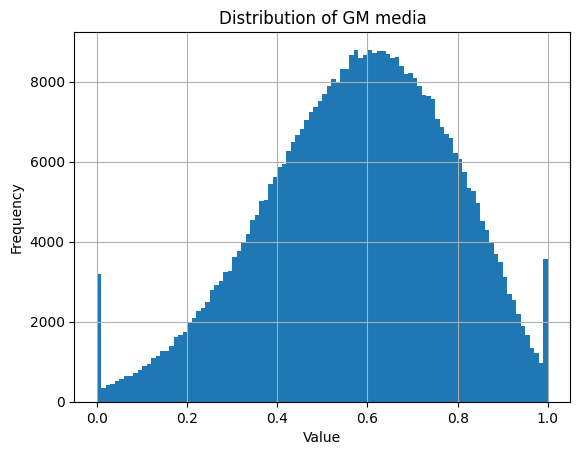

In [14]:
rsfmri_vectors_regression_corrected_norm.stack().hist(bins=100)
plt.title("Distribution of GM media")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()



## Harmonization Using ComBat (with Control Subjects)

This section applies ComBat harmonization to correct for batch effects (e.g., acquisition site) in the rsfMRI connectivity data. The process includes clinical covariates and control subjects, and excludes small batches to ensure stability.

### Steps Performed:

- **Assign batch labels** using the `SITE` variable derived from `redcap_event_name`. Control subjects are grouped into a single batch called `"control_batch"`.
- **Filter out batches** (`SITE`) with fewer than 3 subjects to avoid introducing NaNs.
- **Align data**: Ensure that both rsfMRI matrices and covariate data are aligned by subject ID.
- **Remove all-zero connections** from the matrices prior to harmonization.
- **Apply ComBat harmonization** using the `neuroHarmonize` package.
- **Restore all-zero columns** to the harmonized data (they are preserved as zeros).
- **Reorder columns** to match the original structure.

### Input:
- rsfMRI connectivity matrices (already normalized and covariate-corrected)
- Clinical data: `SITE`

### Output:
- `rsfmri_vectors_median_combat`: Harmonized data after median imputation
- `rsfmri_vectors_knn_combat`: Harmonized data after KNN imputation

**Example usage:**
```python
model_median, data_combat_median = harmonizationLearn(X_median_clean.values, covars_filtered)


In [15]:
# === 7. Harmonization using ComBat (including controls, safe version) ===

# Create 'SITE' column for batch
clinic_df['SITE'] = clinic_df['redcap_event_name']
clinic_df.loc[clinic_df['controls_ms'] == 0, 'SITE'] = 'control_batch'

print("✅ Batch distribution (after assigning to controls):")
print(clinic_df['SITE'].value_counts())

# Align subjects between clinical data and rsfMRI matrix
common_ids = rsfmri_vectors_regression_corrected_norm.index.intersection(clinic_df.index)

# Prepare covariates and drop subjects with missing values
#covars = clinic_df.loc[common_ids, ['SITE', 'age', 'sex', 'controls_ms']].dropna()
#covars = clinic_df.loc[common_ids, ['SITE', 'age', 'sex', 'controls_ms']]
covars = clinic_df.loc[common_ids, ['SITE']].dropna()

# 🧹 Remove SITE batches with <3 subjects (to prevent NaNs)
site_counts = covars['SITE'].value_counts()
valid_sites = site_counts[site_counts >= 3].index
invalid_sites = site_counts[site_counts < 3].index
print(f"⚠️ Excluding {len(invalid_sites)} SITE(s) with <3 subjects: {invalid_sites.tolist()}")

covars_filtered = covars[covars['SITE'].isin(valid_sites)]
print(f"👥 Subjects before ComBat: {len(covars)} → after filtering: {len(covars_filtered)} (removed: {len(covars) - len(covars_filtered)})")

# Align rsfMRI matrices to filtered covariates
X = rsfmri_vectors_regression_corrected_norm.loc[covars_filtered.index]


# === Detect and remove all-zero columns ===
zero_cols = X.columns[(X == 0).all()]

print(f"⚠️ Median version: {len(zero_cols)} all-zero columns excluded from ComBat")


X_clean = X.drop(columns=zero_cols)


# === Apply ComBat ===
model, data_combat = harmonizationLearn(X_clean.values, covars_filtered)
rsfmri_vectors_combat = pd.DataFrame(data_combat,
                                        index=covars_filtered.index,
                                        columns=X_clean.columns)


# === Add back all-zero columns ===
for col in zero_cols:
    rsfmri_vectors_combat[col] = 0.0


# Restore original column order
rsfmri_vectors_combat = rsfmri_vectors_combat[X.columns]


print("✅ ComBat harmonization completed for both Median and KNN imputations (controls included).")

print(rsfmri_vectors_combat.head()) # Check the first rows of the DataFrame
print(rsfmri_vectors_combat.shape) 
  

✅ Batch distribution (after assigning to controls):
SITE
baseline_arm_1     61
year5_arm_1        57
year3_arm_1        22
control_batch      18
year2_arm_1         5
followup1_arm_1     2
Name: count, dtype: int64
⚠️ Excluding 1 SITE(s) with <3 subjects: ['followup1_arm_1']
👥 Subjects before ComBat: 165 → after filtering: 163 (removed: 2)
⚠️ Median version: 0 all-zero columns excluded from ComBat
✅ ComBat harmonization completed for both Median and KNN imputations (controls included).
              0         1         2         3         4         5     \
002MSVIS  0.521885  0.657980  0.362177  0.484059  0.637617  0.650169   
003MSVIS  0.287557  0.518696  0.562430  0.629432  0.362522  0.494044   
004MSVIS  0.860032  0.176994  0.963773  0.840026  0.631896  0.658909   
005MSVIS  0.631020  0.568069  0.785165  0.475845  0.670130  0.759595   
010MSVIS  0.348889  0.346163  0.623658  0.327398  0.492141  0.740746   

              6         7         8         9     ...      2840      2841  \

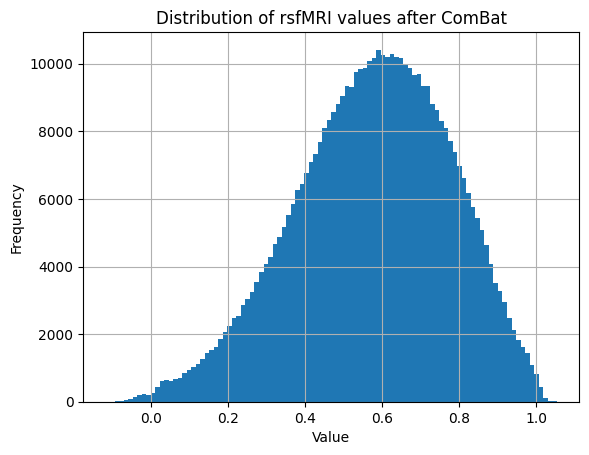

In [16]:
rsfmri_vectors_combat.stack().hist(bins=100)
plt.title("Distribution of rsfMRI values after ComBat")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


## Re-normalization After ComBat (Min-Max Scaling)

After ComBat harmonization, some connection values may rsfmrill outside the original [0, 1] range, including negative values. To ensure compatibility with downstream machine learning models (e.g., GNNs), this step re-applies **Min-Max scaling** to normalize all features between 0 and 1.

- **Function:** `re_normalize_after_combat(df)`
- **Input:** DataFrame of ComBat-harmonized connectivity values.
- **Output:** Re-normalized DataFrame with values in [0, 1].

**Why it's necessary:**
- ComBat adjusts for batch effects but is not bounded by the original data range.
- GNNs and other ML models benefit from consistent input ranges.

**Example usage:**
```python
rsfmri_vectors_median_combat = re_normalize_after_combat(rsfmri_vectors_median_combat)
rsfmri_vectors_knn_combat = re_normalize_after_combat(rsfmri_vectors_knn_combat)


In [17]:

def re_normalize_after_combat(df):
    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df),
        index=df.index,
        columns=df.columns
    )
    return df_scaled

# Re-normalize median and knn versions after ComBat
rsfmri_vectors_combat_re = re_normalize_after_combat(rsfmri_vectors_combat)


In [18]:
zero_cols = rsfmri_vectors_combat.columns[(rsfmri_vectors_combat == 0).all()]
num_zero = len(zero_cols)
print(f"⚠️ {num_zero} all-zero columns.")

print(rsfmri_vectors_combat.shape) 

⚠️ 0 all-zero columns.
(163, 2850)


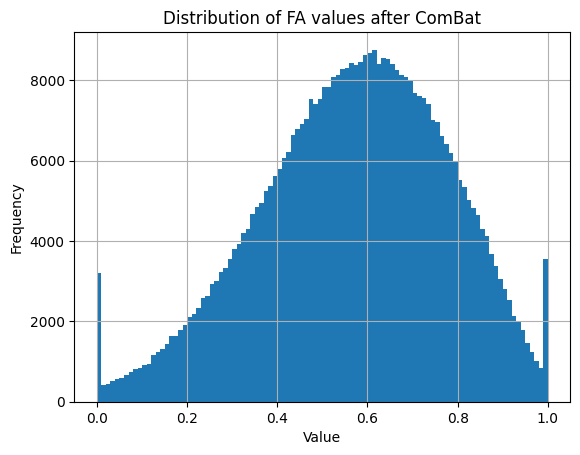

In [19]:
rsfmri_vectors_combat_re.stack().hist(bins=100)
plt.title("Distribution of FA values after ComBat")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


## Mask Weak Connections (Based on Control Subjects)

This function masks (sets to zero) brain connections that are weak in the majority of control subjects. A connection is considered weak if its value is below a specified threshold in more than a given proportion of controls. This helps remove noisy or unreliable connections before further analysis.

- **Function:** `mask_weak_connections(vectors_df, clinic_df, threshold=0.1, max_ratio=0.6)`
- **Inputs:**
  - `vectors_df`: DataFrame of vectorized connectivity matrices.
  - `clinic_df`: Clinical data containing a `controls_ms` column (0 = control).
  - `threshold`: Minimum value to consider a connection strong.
  - `max_ratio`: Maximum allowable proportion of controls with weak connections.
- **Outputs:**
  - `vectors_masked`: DataFrame with weak connections zeroed out.
  - `to_mask`: List of columns (connections) that were masked.
  - `zero_cols_after_masking`: Columns that became completely zero after masking.

### Process:
- Identifies control subjects.
- Computes the proportion of controls with values < `threshold` per connection.
- If this proportion exceeds `max_ratio`, the connection is masked (set to 0.0) in **all** subjects.
- Tracks columns that became entirely zero as a result.

**Example usage:**
```python
rsfmri_vectors_median_combat_masked, masked_median, zero_median = mask_weak_connections(
    rsfmri_vectors_median_combat, clinic_df, threshold=0.1, max_ratio=0.6)


In [20]:
# === 8. Mask weak connections (with zero-column detection) ===

def mask_weak_connections(vectors_df, clinic_df, threshold=0.1, max_ratio=0.6):
    """
    Mask connections where > max_ratio of controls have values below a threshold.
    Replaces those columns with zeros (instead of removing them).
    Also detects columns that are completely zero after masking.

    Args:
        vectors_df (DataFrame): Matrix of vectorized connectomes (subjects x connections).
        clinic_df (DataFrame): DataFrame with 'controls_ms' column.
        threshold (float): Weak connection threshold.
        max_ratio (float): Max proportion of controls allowed below threshold.

    Returns:
        vectors_masked (DataFrame): Same shape as input, with weak connections masked to 0.0
        to_mask (list): List of columns that were masked
        zero_cols_after_masking (list): Columns that became all-zero
    """
    # Identify controls
    control_ids = clinic_df[clinic_df['controls_ms'] == 0].index
    controls_matrix = vectors_df.loc[vectors_df.index.intersection(control_ids)]

    # Calculate proportion of controls below threshold per connection
    weak_ratio = (controls_matrix < threshold).sum(axis=0) / len(controls_matrix)
    to_mask = weak_ratio[weak_ratio > max_ratio].index

    print(f"⚠️ Masked {len(to_mask)} weak connections (threshold < {threshold} in > {int(max_ratio*100)}% of controls)")

    # Apply masking (zero out columns)
    vectors_masked = vectors_df.copy()
    for col in to_mask:
        vectors_masked[col] = 0.0

    # Check for columns that are now all-zero
    zero_cols_after_masking = vectors_masked.columns[(vectors_masked == 0).all()]
    print(f"🧯 Columns now completely zero after masking: {len(zero_cols_after_masking)}")

    return vectors_masked, list(to_mask), list(zero_cols_after_masking)

# Apply masking to ComBat-corrected matrices
rsfmri_vectors_combat_masked_re, masked, zero = mask_weak_connections(
    rsfmri_vectors_combat_re, clinic_df, threshold=0.1, max_ratio=0.6)

rsfmri_vectors_combat_masked, masked, zero = mask_weak_connections(
    rsfmri_vectors_combat, clinic_df, threshold=0.1, max_ratio=0.6)


⚠️ Masked 0 weak connections (threshold < 0.1 in > 60% of controls)
🧯 Columns now completely zero after masking: 0
⚠️ Masked 0 weak connections (threshold < 0.1 in > 60% of controls)
🧯 Columns now completely zero after masking: 0


## Reconstruct and Save Corrected Connectivity Matrices

This function reconstructs full symmetric connectivity matrices (e.g., 76×76) from the vectorized format and saves each subject's corrected matrix as a `.csv` file.

- **Function:** `reconstruct_and_save(corrected_vectors, original_triu_idx, output_dir, n_nodes=76)`
- **Inputs:**
  - `corrected_vectors`: DataFrame of corrected vectorized matrices (`subjects × connections`)
  - `original_triu_idx`: Tuple of indices used during vectorization (upper triangle)
  - `output_dir`: Path where the reconstructed matrices will be saved
  - `n_nodes`: Number of brain regions (nodes) per matrix (dersfmriult: 76)

### Process:
- Initializes a zero-filled vector for each subject's connections.
- Reconstructs the full symmetric matrix using the upper triangle indices.
- Saves each matrix to a `.csv` file named `{subject_id}_rsfMRI_corrected.csv`.

**Example usage:**
```python
reconstruct_and_save(
    corrected_vectors=rsfmri_vectors_median_combat,
    original_triu_idx=triu_idx,
    output_dir="path/to/save_dir",
    n_nodes=76
)


In [21]:
# === 9A. Reconstruct and save corrected matrices ===
def reconstruct_and_save(corrected_vectors, original_triu_idx, output_dir, n_nodes=76):
    """
    Reconstruct and save corrected connectivity matrices preserving the original shape (n_nodes x n_nodes).

    Args:
        corrected_vectors (DataFrame): Corrected vectorized matrices.
        original_triu_idx (tuple): Indices of upper triangle used in vectorization.
        output_dir (str): Path to save the corrected matrices.
        n_nodes (int): Number of nodes in the connectivity matrices.
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Number of unique connections (upper triangle)
    total_connections = len(original_triu_idx[0])

    # Process each subject individually
    for subj in corrected_vectors.index:
        # Initialize full connection vector (including any missing positions as zero)
        full_vector = np.zeros(total_connections)
        valid_cols = [col for col in corrected_vectors.columns]
        full_vector[valid_cols] = corrected_vectors.loc[subj].values

        # Reconstruct full symmetric matrix
        matrix = np.zeros((n_nodes, n_nodes))
        matrix[original_triu_idx] = full_vector
        matrix = matrix + matrix.T # make it symmetric

        # Save the matrix to CSV
        output_path = os.path.join(output_dir, f"{subj}_rsfMRI_corrected.csv")
        pd.DataFrame(matrix).to_csv(output_path, index=False, header=False)

    print(f"✅ Corrected matrices saved in: {output_dir}")

# Save corrected matrices
reconstruct_and_save(
    corrected_vectors=rsfmri_vectors_combat_masked,
    original_triu_idx=triu_idx,
    output_dir="F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/corrected_rsfMRI_matrices_regression",
    n_nodes=76 # Dimensions of the matrix (76x76) - Original and corrected   
)

reconstruct_and_save(
    corrected_vectors=rsfmri_vectors_combat_masked_re,
    original_triu_idx=triu_idx,
    output_dir="F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/corrected_rsfMRI_matrices_regression_re",
    n_nodes=76 # Dimensions of the matrix (76x76) - Original and corrected   
)



✅ Corrected matrices saved in: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/corrected_rsfMRI_matrices_regression
✅ Corrected matrices saved in: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/corrected_rsfMRI_matrices_regression_re


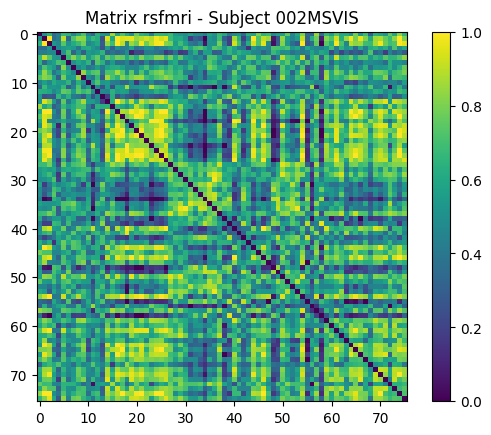

In [22]:
# Rebuild the original matrix from the vector
# 1. Get the first vector
first_subject_id = rsfmri_vectors_combat_masked_re.index[0]
first_vector = rsfmri_vectors_combat_masked_re.loc[first_subject_id].values

# 2. Get the size of the original matrix (e.g., 76x76)  
matrix_size = next(iter(rsfmri_matrices.values())).shape[0]

# 3. Create an empty matrix
reconstructed_matrix = np.zeros((matrix_size, matrix_size))

# 4. Insert the values from the vector into the upper triangle  
i_indices, j_indices = triu_idx

# 5. Copy symmetrically to the lower triangle
reconstructed_matrix[i_indices, j_indices] = first_vector

# 6. Plot the matrix    
reconstructed_matrix[j_indices, i_indices] = first_vector
plt.imshow(reconstructed_matrix, cmap='viridis')
plt.title(f"Matrix rsfmri - Subject {first_subject_id}")
plt.colorbar()
plt.show()

## Compute and Visualize Group Mean Connectivity Matrices (Pre-Correction)

This step computes and visualizes the **mean connectivity matrix** separately for control and patient groups using the raw functional connectivity matrices (before correction or harmonization).

### Functions:
- **`compute_group_mean_matrices(matrices_dict, clinic_df)`**  
  Calculates the mean connectivity matrix for each group (controls and patients), based on the clinical `controls_ms` label (0 = control, 1 = patient).

- **`plot_mean_matrix(matrix, title)`**  
  Displays a heatmap of a mean connectivity matrix using `matplotlib`.

- **`save_mean_matrix(matrix, output_path)`**  
  Saves the mean matrix to a CSV file.

### Outputs:
- Mean matrices for controls and patients (`mean_control`, `mean_patient`)
- Visual comparison of the two groups via heatmaps
- Saved `.csv` files for documentation or further analysis

### Example usage:
```python
mean_control, mean_patient = compute_group_mean_matrices(rsfmri_matrices, clinic_df)
plot_mean_matrix(mean_control, "Mean Connectivity - Controls")
plot_mean_matrix(mean_patient, "Mean Connectivity - Patients")
save_mean_matrix(mean_control, "rsfMRI_mean_connectivity_controls_before.csv")
save_mean_matrix(mean_patient, "rsfMRI_mean_connectivity_patients_before.csv")


✅ Nº controls: 18
✅ Nº patients: 147


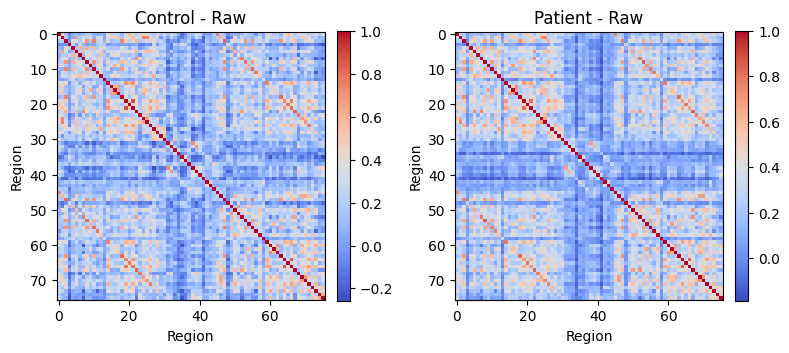

✅ Mean matrix saved to: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/output/rsfMRI_mean_connectivity_controls_before.csv
✅ Mean matrix saved to: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/output/rsfMRI_mean_connectivity_patients_before.csv


In [23]:
# === 9B. Compute and visualize mean matrices by group (control - patient BEFORE correction) ===
def compute_group_mean_matrices(matrices_dict, clinic_df):
    """
    Compute the mean connectivity matrix for controls and patients separately.

    Args:
        matrices_dict (dict): Dictionary {subject_id: connectivity matrix}.
        clinic_df (DataFrame): Clinical data with 'controls_ms' column (0=control, 1=patient).

    Returns:
        mean_control (np.ndarray): Mean matrix for controls.
        mean_patient (np.ndarray): Mean matrix for patients.
    """
    # Get subject IDs per group
    control_ids = clinic_df[clinic_df['controls_ms'] == 0].index
    patient_ids = clinic_df[clinic_df['controls_ms'] == 1].index

    # Extract matrices per group
    control_matrices = [matrices_dict[subj] for subj in control_ids if subj in matrices_dict]
    patient_matrices = [matrices_dict[subj] for subj in patient_ids if subj in matrices_dict]

    # Compute mean matrices
    mean_control = np.mean(control_matrices, axis=0)
    mean_patient = np.mean(patient_matrices, axis=0)  

    print(f"✅ Nº controls: {len(control_matrices)}")
    print(f"✅ Nº patients: {len(patient_matrices)}")

    return mean_control, mean_patient

def plot_multiple_matrices_grid(matrices, titles, cmap='coolwarm', n_cols=2):
    """
    Plot multiple connectivity matrices in a grid with a configurable number of columns.

    Args:
        matrices (list of np.ndarray): List of matrices to display.
        titles (list of str): Corresponding titles for each matrix.
        cmap (str): Colormap for the heatmaps.
        n_cols (int): Number of columns in the plot grid (default: 2).
    """
    assert len(matrices) == len(titles), "Length of matrices and titles must match"

    n = len(matrices)
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

    # If there's only one row, ensure axes is a 1D array
    if n_rows == 1:
        axes = np.array(axes).reshape(1, -1)
    elif n_cols == 1:
        axes = np.array(axes).reshape(-1, 1)

    axes = axes.flatten()

    for i, (matrix, title) in enumerate(zip(matrices, titles)):
        ax = axes[i]
        im = ax.imshow(matrix, cmap=cmap, vmin=np.min(matrix), vmax=np.max(matrix))
        ax.set_title(title)
        ax.set_xlabel("Region")
        ax.set_ylabel("Region")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show() 

def save_mean_matrix(matrix, output_path):
    """
    Save the mean matrix to CSV.
    
    Args:
        matrix (np.ndarray): Matrix to save.
        output_path (str): File path to save the CSV.
    """
    pd.DataFrame(matrix).to_csv(output_path, index=False, header=False)
    print(f"✅ Mean matrix saved to: {output_path}")

# Execution calculation, visualization and saving   
# Compute mean matrices for controls and patients
mean_control, mean_patient = compute_group_mean_matrices(rsfmri_matrices, clinic_df)

# Visualization
plot_multiple_matrices_grid(
    matrices=[mean_control,
               mean_patient],
    titles=[
        "Control - Raw", 
        "Patient - Raw"],
        n_cols=2
)

# Save mean matrices
save_mean_matrix(mean_control, "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/output/rsfMRI_mean_connectivity_controls_before.csv")
save_mean_matrix(mean_patient, "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/output/rsfMRI_mean_connectivity_patients_before.csv")


## Compute and Visualize Group Mean Connectivity Matrices (Post-Correction)

This step reconstructs and visualizes the **mean corrected connectivity matrices** for control and patient groups, using data that has been imputed, covariate-corrected, batch-harmonized (ComBat), re-normalized, and optionally masked.

### Function: `compute_group_mean_corrected`
Reconstructs symmetric connectivity matrices from the corrected vectorized format and computes the mean matrix separately for controls and patients.

- **Inputs:**
  - `corrected_vectors`: DataFrame of corrected and masked vectorized matrices.
  - `original_triu_idx`: Upper triangle indices used during vectorization.
  - `clinic_df`: Clinical data with group labels (column `'GROUP'`: 0 = control, 1 = patient).
  - `n_nodes`: Size of the connectivity matrix (dersfmriult: 76).

- **Outputs:**
  - `mean_control`: Mean connectivity matrix for controls.
  - `mean_patient`: Mean connectivity matrix for patients.

### Visualization and Export:
- Uses `plot_mean_matrix()` to visualize the mean matrices.
- Saves the resulting matrices to `.csv` files for future use or documentation.

**Example usage:**
```python
mean_control_median, mean_patient_median = compute_group_mean_corrected(
    corrected_vectors=rsfmri_vectors_median_combat_masked,
    original_triu_idx=triu_idx,
    clinic_df=clinic_df,
    n_nodes=76
)

plot_mean_matrix(mean_control_median, "Mean Corrected (Median) - Controls")
plot_mean_matrix(mean_patient_median, "Mean Corrected (Median) - Patients")

save_mean_matrix(mean_control_median, "rsfMRI_mean_corrected_controls_median.csv")


✅ Nº controls (corrected): 18
✅ Nº patients (corrected): 145
✅ Nº controls (corrected): 18
✅ Nº patients (corrected): 145


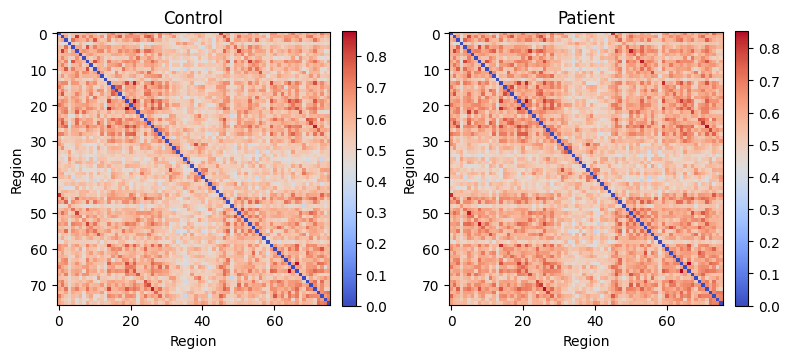

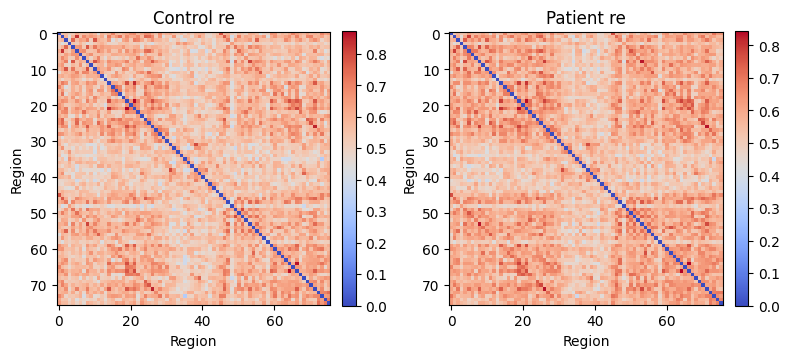

✅ Mean matrix saved to: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/output/rsfMRI_corrected_controls_regression.csv
✅ Mean matrix saved to: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/output/rsfMRI_corrected_patients_regression.csv
✅ Mean matrix saved to: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/output/rsfMRI_corrected_controls_regression_re.csv
✅ Mean matrix saved to: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/output/rsfMRI_corrected_patients_regression_re.csv


In [24]:

# === 9C. Compute and visualize mean matrices AFTER correction ===
def compute_group_mean_corrected(corrected_vectors, original_triu_idx, clinic_df, n_nodes=76):
    """
    Compute the mean corrected connectivity matrix for controls and patients separately.

    Args:
        corrected_vectors (DataFrame): Corrected vectorized matrices.
        original_triu_idx (tuple): Upper triangle indices.
        clinic_df (DataFrame): Clinical data with 'controls_ms' column.
        n_nodes (int): Matrix size.

    Returns:
        mean_control (np.ndarray): Mean matrix for controls.
        mean_patient (np.ndarray): Mean matrix for patients.
    """
    # Get subject IDs per group
    control_ids = clinic_df[clinic_df['controls_ms'] == 0].index
    patient_ids = clinic_df[clinic_df['controls_ms'] == 1].index

    # Reconstruct matrices per subject
    matrices_control = []
    matrices_patient = []

    total_connections = len(original_triu_idx[0])

    for subj in corrected_vectors.index:
        # Build full connection vector (including zero-filled positions if needed)
        full_vector = np.zeros(total_connections)
        valid_cols = [col for col in corrected_vectors.columns]
        full_vector[valid_cols] = corrected_vectors.loc[subj].values

        # Reconstruct full matrix
        matrix = np.zeros((n_nodes, n_nodes))
        matrix[original_triu_idx] = full_vector
        matrix = matrix + matrix.T

         # Assign to group
        if subj in control_ids:
            matrices_control.append(matrix)
        elif subj in patient_ids:
            matrices_patient.append(matrix)

    # Compute mean matrices
    mean_control = np.mean(matrices_control, axis=0)
    mean_patient = np.mean(matrices_patient, axis=0)

    print(f"✅ Nº controls (corrected): {len(matrices_control)}")
    print(f"✅ Nº patients (corrected): {len(matrices_patient)}")

    return mean_control, mean_patient

#  Execution calculation, visualization and saving 
# Compute mean matrices for controls and patients (median & knn corrected)
mean_control, mean_patient = compute_group_mean_corrected(
    corrected_vectors=rsfmri_vectors_combat_masked,
    original_triu_idx=triu_idx,
    clinic_df=clinic_df,
    n_nodes=76
)

mean_control_re, mean_patient_re = compute_group_mean_corrected(
    corrected_vectors=rsfmri_vectors_combat_masked_re,
    original_triu_idx=triu_idx,
    clinic_df=clinic_df,
    n_nodes=76
)


# Visualization
plot_multiple_matrices_grid(
    matrices=[mean_control,mean_patient],
    titles=["Control", "Patient"],
        n_cols=2
)
plot_multiple_matrices_grid(
    matrices=[mean_control_re,mean_patient_re],
    titles=["Control re", "Patient re"],
        n_cols=2
)

#  Save  matrices 
save_mean_matrix(mean_control, "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/output/rsfMRI_corrected_controls_regression.csv")
save_mean_matrix(mean_patient, "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/output/rsfMRI_corrected_patients_regression.csv")

save_mean_matrix(mean_control_re, "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/output/rsfMRI_corrected_controls_regression_re.csv")
save_mean_matrix(mean_patient_re, "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/output/rsfMRI_corrected_patients_regression_re.csv")


## Demographic and Clinical Stratification (Age / Sex)

This section compares the demographic characteristics (age and sex) between the control and patient groups. It performs statistical tests to detect significant group differences and visualizes the distributions.

### Statistical Tests:
- **Age:** Independent two-sample *t*-test (Welch's t-test) is used to compare the age distributions between controls and patients.
- **Sex:** Chi-squared test is used to assess differences in sex proportions between the two groups.

### Visualizations:
- **Boxplot:** Shows the distribution of age by group.
- **Countplot:** Displays the number of males and females in each group.

**Example outputs:**
- `p_age`: *p*-value for the age difference.
- `p_sex`: *p*-value for the sex distribution difference.

**Example code:**
```python
t_stat, p_age = ttest_ind(controls['age'], patients['age'], equal_var=False)
chi2, p_sex, _, _ = chi2_contingency(pd.crosstab(clinic_df['controls_ms'], clinic_df['sex']))


🧠 Age - t-test p-value = 0.0002
🧠 Sex - chi-squared p-value = 0.3978


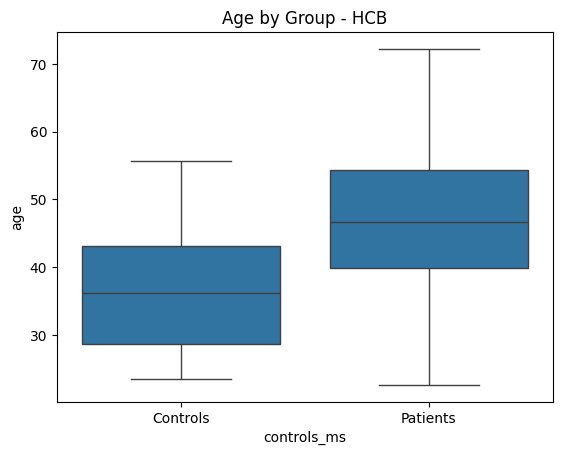

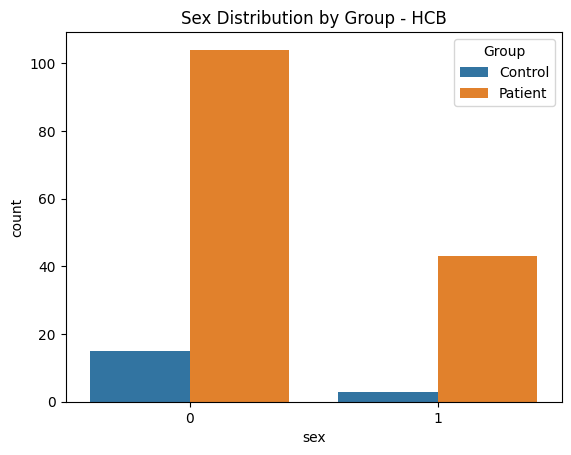

In [25]:
# === 10A. Demographic and clinical stratification (Age / Sex) ===

# Split data by group
controls = clinic_df[clinic_df['controls_ms'] == 0]
patients = clinic_df[clinic_df['controls_ms'] == 1]

# Age: t-test
t_stat, p_age = ttest_ind(controls['age'].dropna(), patients['age'].dropna(), equal_var=False)
print(f"🧠 Age - t-test p-value = {p_age:.4f}")

# Sex: chi-square
sex_table = pd.crosstab(clinic_df['controls_ms'], clinic_df['sex'])
chi2, p_sex, _, _ = chi2_contingency(sex_table)
print(f"🧠 Sex - chi-squared p-value = {p_sex:.4f}")

# Boxplot age
sns.boxplot(x='controls_ms', y='age', data=clinic_df)
plt.xticks([0, 1], ['Controls', 'Patients'])
plt.title("Age by Group - HCB")
plt.show()

# Count sex
sns.countplot(x='sex', hue='controls_ms', data=clinic_df)
plt.legend(title='Group', labels=['Control', 'Patient'])
plt.title("Sex Distribution by Group - HCB")
plt.show()


## Clinical Stratification: Disease Duration (DD) and Disability (EDSS)

This section analyzes clinical variability **within the patient group** by stratifying them based on disease duration (`dd`) and exploring differences in disability scores (`EDSS`).

### Steps:
- **Disease Duration Binning:** Patients are categorized into 5 groups based on `dd` (disease duration in years):
  - `<2`, `2–5`, `5–10`, `10–20`, `20+`
- **Group Count:** Displays the number of patients in each duration group.
- **Visualization:** A boxplot shows how `EDSS` (disability score) varies across different `dd` groups.

### Example Code:
```python
bins = [0, 2, 5, 10, 20, 100]
labels = ['<2', '2–5', '5–10', '10–20', '20+']
patients['dd_grp'] = pd.cut(patients['dd'], bins=bins, labels=labels)

sns.boxplot(x='dd_grp', y='edss', data=patients)


C:\Users\alvar\AppData\Local\Temp\ipykernel_12212\847271716.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patients['dd_grp'] = pd.cut(patients['dd'], bins=bins, labels=labels)


dd_grp
10–20    65
5–10     40
20+      38
2–5       4
<2        0
Name: count, dtype: int64


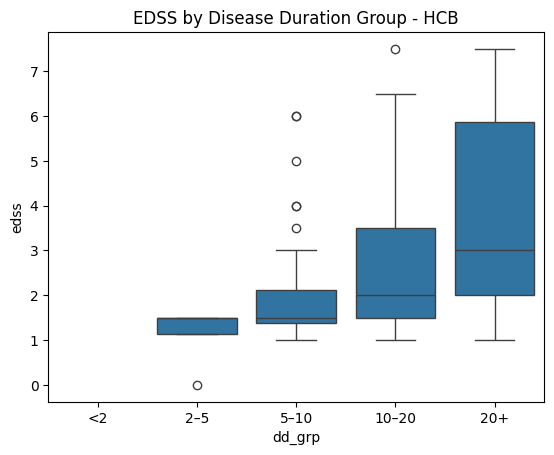

In [26]:
# === 10B. Demographic and clinical stratification (DD / EDSS) ===
# Patients only
# Group by dd (disease duration) and count
bins = [0, 2, 5, 10, 20, 100]
labels = ['<2', '2–5', '5–10', '10–20', '20+']
# Create a new column 'dd_grp' to categorize the disease duration
patients['dd_grp'] = pd.cut(patients['dd'], bins=bins, labels=labels)

# Show the counts of each group
print(patients['dd_grp'].value_counts())

# Visualization
sns.boxplot(x='dd_grp', y='edss', data=patients)
plt.title("EDSS by Disease Duration Group - HCB")
plt.show()


## Clinical Stratification: MS Type and Disease Duration

This section analyzes disease duration (`DD`) across different **Multiple Sclerosis (MS) subtypes**, providing insight into how progression may differ by clinical phenotype.

### MS Types Included:
- `RRMS`: Relapsing-Remitting MS
- `SPMS`: Secondary Progressive MS
- `PPMS`: Primary Progressive MS

These types are mapped from the `GROUP_MS` column, which uses short codes (`'RR'`, `'SP'`, `'PP'`).

### Steps:
- Converts MS subtype codes into readable labels.
- Counts the number of patients in each subtype group.
- Visualizes the distribution of **disease duration (DD)** across MS types using a boxplot.

**Example Code:**
```python
mstype_labels = {'RR': 'RRMS', 'SP': 'SPMS', 'PP': 'PPMS'}
patients['mstype_label'] = patients['GROUP_MS'].map(mstype_labels)

sns.boxplot(x='mstype_label', y='DD', data=patients)


C:\Users\alvar\AppData\Local\Temp\ipykernel_12212\3611333576.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patients['mstype_label'] = patients['mstype'].map(mstype_labels)


mstype_label
RRMS    125
SPMS     16
PPMS      6
Name: count, dtype: int64


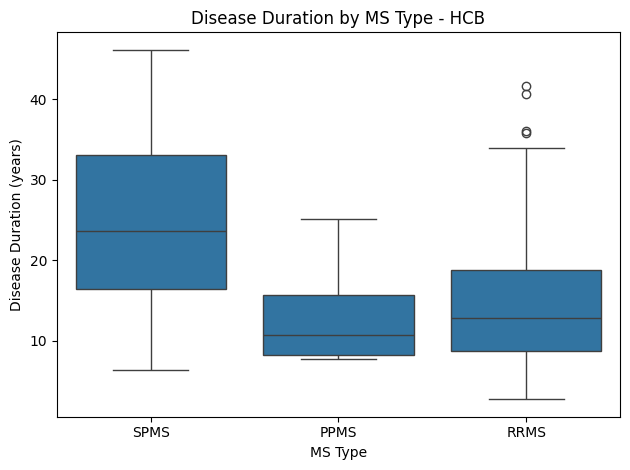

In [27]:
# === 10C. Demographic and clinical stratification (DD / MsType) ===
# Patients only
# Types EM: (0) RRMS, (1) SPMS y (2) PPMS
# 0 RRMS – Remitting-Relapsing 	
# 1 SPMS – Secondary Progressive 
# 2 PPMS – Primary Progressive 
# Map numerical MS types to readable labels
mstype_labels = {0: 'RRMS', 1: 'SPMS', 2: 'PPMS'}
patients['mstype_label'] = patients['mstype'].map(mstype_labels)

# Show count of each MS type
print(patients['mstype_label'].value_counts())

# Boxplot of disease duration by MS type
sns.boxplot(x='mstype_label', y='dd', data=patients)
plt.title("Disease Duration by MS Type - HCB")
plt.xlabel("MS Type")
plt.ylabel("Disease Duration (years)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Clinical Stratification: EDSS Severity Levels and Disease Duration

This section categorizes **patients** based on their **EDSS (Expanded Disability Status Scale)** scores, providing a clinical severity stratification. It then explores how disease duration (`dd`) varies across these severity levels.

### EDSS Severity Groups:
- `0–2`: Mild
- `2–4`: Moderate
- `4–6.5`: Moderate-Severe
- `6.5–9`: Severe
- `9–10`: Very Severe

### Steps:
- Bins EDSS scores into clinically meaningful categories.
- Counts the number of patients per severity group.
- Visualizes **disease duration** across EDSS severity groups using a boxplot.

**Example Code:**
```python
edss_bins = [0, 2, 4, 6.5, 9, 10]
edss_labels = ['0–2 (Mild)', '2–4 (Moderate)', '4–6.5 (Moderate-Severe)', '6.5–9 (Severe)', '9–10 (Very Severe)']
patients['edss_group'] = pd.cut(patients['edss'], bins=edss_bins, labels=edss_labels)

sns.boxplot(x='edss_group', y='dd', data=patients)


C:\Users\alvar\AppData\Local\Temp\ipykernel_12212\934641050.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patients['edss_group'] = pd.cut(patients['edss'], bins=edss_bins, labels=edss_labels)


📊 Patients per EDSS severity group:
edss_group
0–2 (Mild)                 84
2–4 (Moderate)             35
4–6.5 (Moderate-Severe)    25
6.5–9 (Severe)              2
9–10 (Very Severe)          0
Name: count, dtype: int64


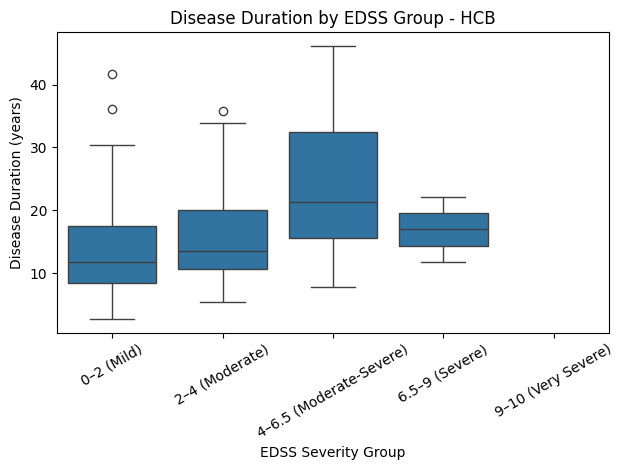

In [28]:
# === 10D. Demographic and clinical stratification (EDSS / Severity) ===
# Patients only
# Define EDSS severity bins
edss_bins = [0, 2, 4, 6.5, 9, 10]
edss_labels = [
    '0–2 (Mild)',
    '2–4 (Moderate)',
    '4–6.5 (Moderate-Severe)',
    '6.5–9 (Severe)',
    '9–10 (Very Severe)'
]

# Assign EDSS severity group
patients['edss_group'] = pd.cut(patients['edss'], bins=edss_bins, labels=edss_labels)

# Display group distribution
print("📊 Patients per EDSS severity group:")
print(patients['edss_group'].value_counts().sort_index())

# Visualize duration vs EDSS level
sns.boxplot(x='edss_group', y='dd', data=patients)
plt.title("Disease Duration by EDSS Group - HCB")
plt.xlabel("EDSS Severity Group")
plt.ylabel("Disease Duration (years)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Merge Clinical Stratification Variables into Main Clinical DataFrame

This step integrates the newly computed clinical stratification variables back into the main `clinic_df` DataFrame, ensuring that all relevant information is centrally available for downstream analysis or modeling.

### Variables Added:
- `dd_grp`: Disease duration group (binned)
- `mstype_label`: MS clinical subtype (`RRMS`, `SPMS`, `PPMS`)
- `edss_group`: EDSS-based severity group

### Process:
- Selects these columns from the `patients` DataFrame.
- Merges them into `clinic_df` by matching subject IDs.

**Example Code:**
```python
columns_to_add = ['dd_grp', 'mstype_label', 'edss_group']
clinic_df.loc[clinic_df.index.intersection(patients.index), columns_to_add] = (
    patients.loc[clinic_df.index.intersection(patients.index), columns_to_add]
)


In [29]:
# === 10E. Add clinical data to clinic_df ===
# Select columns to transfer from patients to clinic_df
columns_to_add = ['dd_grp', 'mstype_label', 'edss_group']

# Match and assign values where IDs are common
clinic_df.loc[clinic_df.index.intersection(patients.index), columns_to_add] = (
    patients.loc[clinic_df.index.intersection(patients.index), columns_to_add]
)

# Display result to confirm columns were added
print("✅ Columns successfully added to clinic_df:")
print(clinic_df[columns_to_add].info())


✅ Columns successfully added to clinic_df:
<class 'pandas.core.frame.DataFrame'>
Index: 165 entries, 002MSVIS to sFIS_09
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   dd_grp        147 non-null    category
 1   mstype_label  147 non-null    object  
 2   edss_group    146 non-null    category
dtypes: category(2), object(1)
memory usage: 7.4+ KB
None


In [30]:
# Make sure 'Control' is added as a category before filling NaNs
for col in columns_to_add:
    if pd.api.types.is_categorical_dtype(clinic_df[col]):
        if 'Control' not in clinic_df[col].cat.categories:
            clinic_df[col] = clinic_df[col].cat.add_categories('Control')
            
# Now safely fill NaNs with 'Control'
clinic_df[columns_to_add] = clinic_df[columns_to_add].fillna('Control')

# Check result
print("✅ NaNs filled with 'Control' in categorical columns:")
print(clinic_df[columns_to_add].head())


✅ NaNs filled with 'Control' in categorical columns:
         dd_grp mstype_label               edss_group
id                                                   
002MSVIS    20+         SPMS           6.5–9 (Severe)
003MSVIS   5–10         PPMS  4–6.5 (Moderate-Severe)
004MSVIS   5–10         RRMS           2–4 (Moderate)
005MSVIS   5–10         RRMS               0–2 (Mild)
010MSVIS   5–10         RRMS               0–2 (Mild)


C:\Users\alvar\AppData\Local\Temp\ipykernel_12212\1539784892.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(clinic_df[col]):


## Compute and Visualize Group Mean Connectivity Matrices by Clinical Stratification

This section computes mean connectivity matrices for **custom-defined clinical subgroups**, such as disease duration (`dd_grp`), MS type (`mstype_label`), and EDSS severity (`edss_group`). It allows detailed subgroup-level analysis of brain connectivity.

---

### Function: `compute_group_mean_from_dataframe()`

Reconstructs full symmetric matrices from the vectorized DataFrame and computes a mean connectivity matrix per group based on a specified column from `clinic_df`.

- **Inputs:**
  - `vectors_df`: Corrected and masked vectorized connectivity matrices.
  - `clinic_df`: Clinical metadata including grouping column (e.g., `'dd_grp'`).
  - `group_col`: Column in `clinic_df` used to define groups.
  - `original_triu_idx`: Tuple with upper triangle indices.
  - `n_nodes`: Number of brain regions.

- **Output:**
  - Dictionary `{group_name: mean_connectivity_matrix}`

---

### Function: `plot_group_mean_matrices()`

Plots the heatmaps of mean matrices for each group using `matplotlib`.

- **Input:** Dictionary of mean matrices per group (from previous function).
- **Optional arguments:**
  - `title_prefix`: Text added before the group name in plot titles.
  - `cmap`: Colormap used for visualization (dersfmriult: `'coolwarm'`).

---

### Example Applications:
```python
mean_matrices_dd = compute_group_mean_from_dataframe(
    vectors_df=rsfmri_vectors_median_combat_masked,
    clinic_df=clinic_df,
    group_col='dd_grp',
    original_triu_idx=triu_idx,
    n_nodes=76
)

plot_group_mean_matrices(mean_matrices_dd, title_prefix="Mean Connectivity (Median) - DD Group")


In [31]:
def compute_group_mean_from_dataframe(vectors_df, clinic_df, group_col, original_triu_idx, n_nodes=76):
    """
    Compute mean connectivity matrices from corrected vectorized DataFrame per group.

    Args:
        vectors_df (DataFrame): DataFrame with vectorized connectivity per subject.
        clinic_df (DataFrame): Clinical DataFrame with group information.
        group_col (str): Column in clinic_df to group by (e.g., 'dd_grp').
        original_triu_idx (tuple): Indices used in upper triangle vectorization.
        n_nodes (int): Number of regions (matrix size).

    Returns:
        dict: {group_name: mean_matrix (np.ndarray)}
    """
    total_connections = len(original_triu_idx[0])
    group_matrices = {}

    for group, group_df in clinic_df.groupby(group_col):
        subject_ids = group_df.index.intersection(vectors_df.index)

        matrices = []
        for subj in subject_ids:
            full_vector = np.zeros(total_connections)
            full_vector[list(vectors_df.columns)] = vectors_df.loc[subj].values

            matrix = np.zeros((n_nodes, n_nodes))
            matrix[original_triu_idx] = full_vector
            matrix = matrix + matrix.T
            matrices.append(matrix)

        if matrices:
            group_matrices[group] = np.mean(matrices, axis=0)
            print(f"✅ Group '{group}' → {len(matrices)} subjects")
        else:
            print(f"⚠️ Group '{group}' has no subjects with data")

    return group_matrices

# Mean matrices per disease duration group
mean_matrices_dd = compute_group_mean_from_dataframe(
    vectors_df=rsfmri_vectors_combat_masked,
    clinic_df=clinic_df,
    group_col='dd_grp',
    original_triu_idx=triu_idx,
    n_nodes=76
)

mean_matrices_dd_re = compute_group_mean_from_dataframe(
    vectors_df=rsfmri_vectors_combat_masked_re,
    clinic_df=clinic_df,
    group_col='dd_grp',
    original_triu_idx=triu_idx,
    n_nodes=76
)


# Mean matrices per MS type
mean_matrices_mstype = compute_group_mean_from_dataframe(
    vectors_df=rsfmri_vectors_combat_masked,
    clinic_df=clinic_df,
    group_col='mstype_label',
    original_triu_idx=triu_idx,
    n_nodes=76
)

mean_matrices_mstype_re = compute_group_mean_from_dataframe(
    vectors_df=rsfmri_vectors_combat_masked_re,
    clinic_df=clinic_df,
    group_col='mstype_label',
    original_triu_idx=triu_idx,
    n_nodes=76
)


# Mean matrices per EDSS severity group
mean_matrices_edss = compute_group_mean_from_dataframe(
    vectors_df=rsfmri_vectors_combat_masked,
    clinic_df=clinic_df,
    group_col='edss_group',
    original_triu_idx=triu_idx,
    n_nodes=76
)

mean_matrices_edss_re = compute_group_mean_from_dataframe(
    vectors_df=rsfmri_vectors_combat_masked_re,
    clinic_df=clinic_df,
    group_col='edss_group',
    original_triu_idx=triu_idx,
    n_nodes=76
)


def plot_multiple_group_mean_matrices(matrix_dicts, titles, cmap="coolwarm", n_cols=4):
    """
    Plot group mean matrices from multiple sources side-by-side.

    Args:
        matrix_dicts (list of dict): Each dict is {group_name: matrix}
        titles (list of str): One title per dict (e.g., Median, KNN, etc.)
        cmap (str): Colormap to use
        n_cols (int): How many matrices per row
    """
    import matplotlib.pyplot as plt

    # Detect all unique group names across all dictionaries
    all_groups = set()
    for d in matrix_dicts:
        all_groups.update(d.keys())
    all_groups = sorted(list(all_groups))

    n_rows = len(all_groups)
    n_total = len(matrix_dicts)

    fig, axes = plt.subplots(n_rows, n_total, figsize=(4 * n_total, 4 * n_rows))

    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for row_idx, group in enumerate(all_groups):
        for dict_idx, matrix_dict in enumerate(matrix_dicts):
            ax = axes[row_idx, dict_idx]
            title_prefix = titles[dict_idx]

            if group in matrix_dict:
                matrix = matrix_dict[group]
                im = ax.imshow(matrix, cmap=cmap)
                ax.set_title(f"{title_prefix} - {group}")
                ax.set_xlabel("Region")
                ax.set_ylabel("Region")
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            else:
                ax.set_visible(False)  # Hide subplot if data is missing

    plt.tight_layout()
    plt.show()



⚠️ Group '<2' has no subjects with data
✅ Group '2–5' → 4 subjects
✅ Group '5–10' → 40 subjects


C:\Users\alvar\AppData\Local\Temp\ipykernel_12212\791719044.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, group_df in clinic_df.groupby(group_col):


✅ Group '10–20' → 63 subjects
✅ Group '20+' → 38 subjects
✅ Group 'Control' → 18 subjects
⚠️ Group '<2' has no subjects with data
✅ Group '2–5' → 4 subjects
✅ Group '5–10' → 40 subjects
✅ Group '10–20' → 63 subjects
✅ Group '20+' → 38 subjects
✅ Group 'Control' → 18 subjects
✅ Group 'Control' → 18 subjects
✅ Group 'PPMS' → 6 subjects
✅ Group 'RRMS' → 124 subjects
✅ Group 'SPMS' → 15 subjects
✅ Group 'Control' → 18 subjects
✅ Group 'PPMS' → 6 subjects
✅ Group 'RRMS' → 124 subjects
✅ Group 'SPMS' → 15 subjects
✅ Group '0–2 (Mild)' → 84 subjects
✅ Group '2–4 (Moderate)' → 34 subjects
✅ Group '4–6.5 (Moderate-Severe)' → 24 subjects
✅ Group '6.5–9 (Severe)' → 2 subjects
⚠️ Group '9–10 (Very Severe)' has no subjects with data
✅ Group 'Control' → 19 subjects


C:\Users\alvar\AppData\Local\Temp\ipykernel_12212\791719044.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, group_df in clinic_df.groupby(group_col):


✅ Group '0–2 (Mild)' → 84 subjects
✅ Group '2–4 (Moderate)' → 34 subjects
✅ Group '4–6.5 (Moderate-Severe)' → 24 subjects
✅ Group '6.5–9 (Severe)' → 2 subjects
⚠️ Group '9–10 (Very Severe)' has no subjects with data
✅ Group 'Control' → 19 subjects


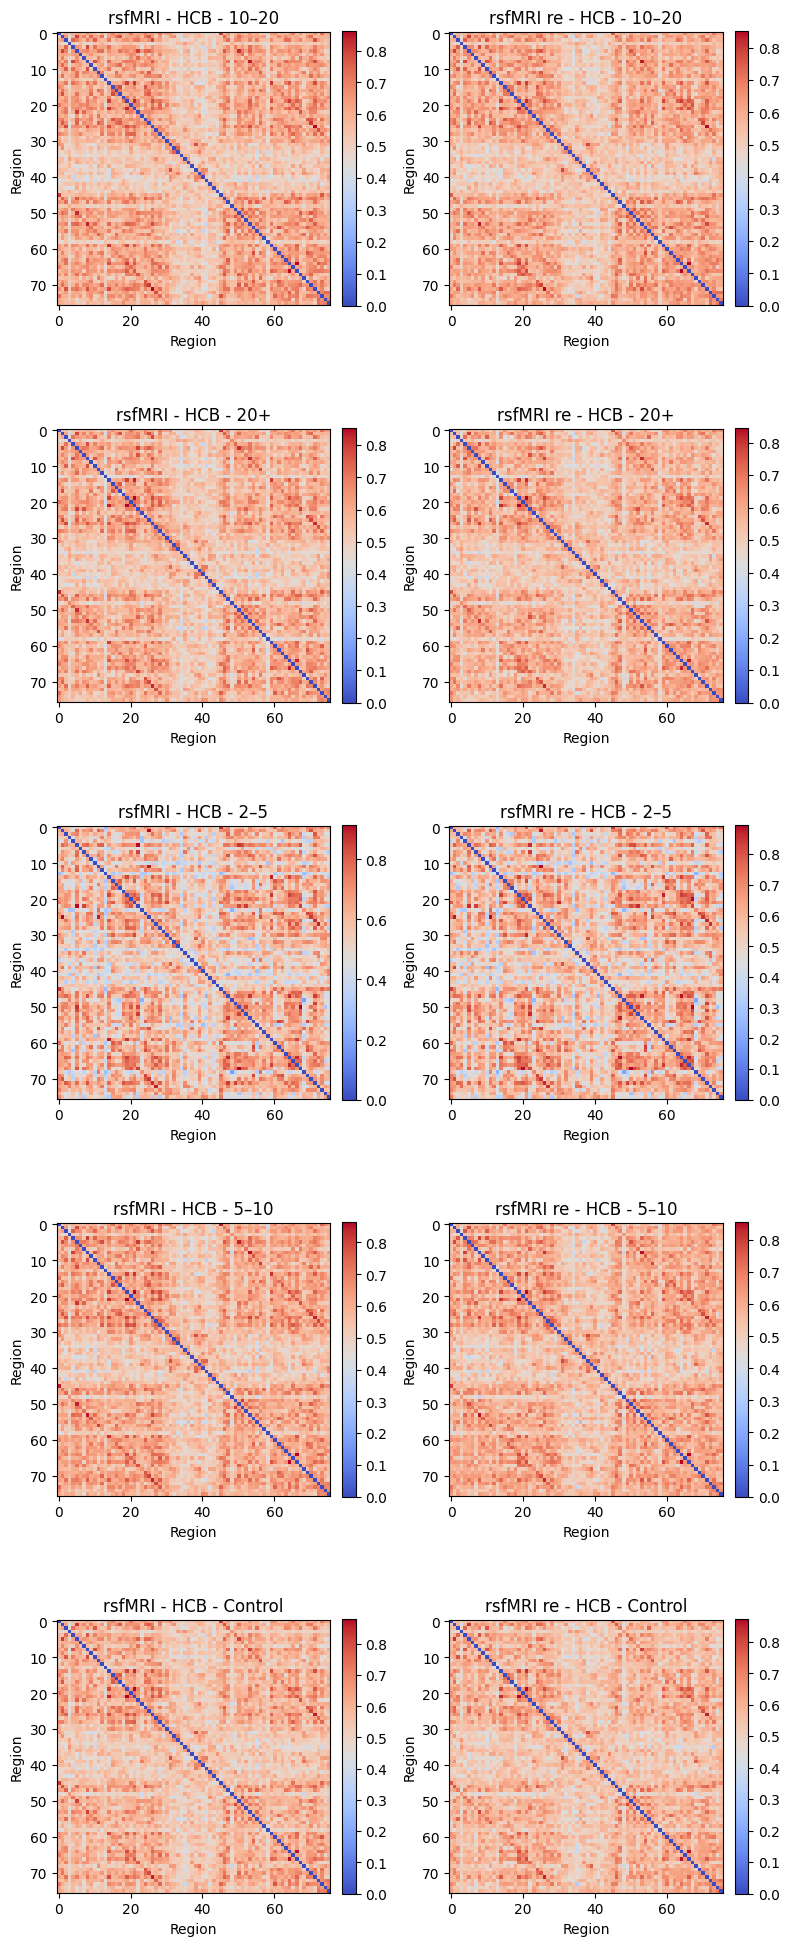

In [32]:
plot_multiple_group_mean_matrices(
    matrix_dicts=[
        mean_matrices_dd,
        mean_matrices_dd_re     
    ],
    titles=[
        "rsfMRI - HCB",
        "rsfMRI re - HCB"
    ],
    
)

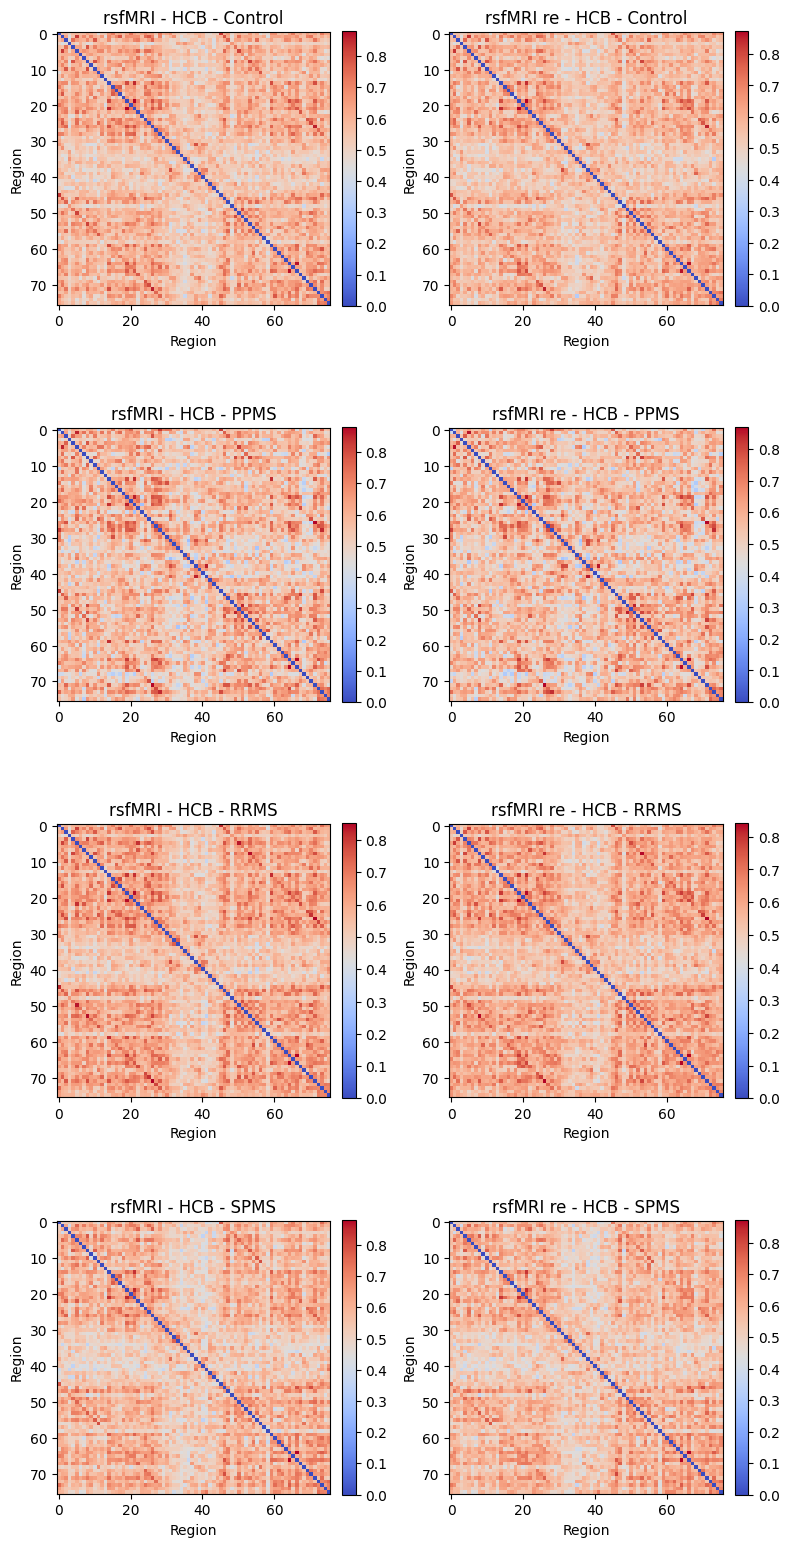

In [33]:
plot_multiple_group_mean_matrices(
    matrix_dicts=[
        mean_matrices_mstype,
        mean_matrices_mstype_re
    ],
    titles=[
        "rsfMRI - HCB",
        "rsfMRI re - HCB"
    ],
 
)

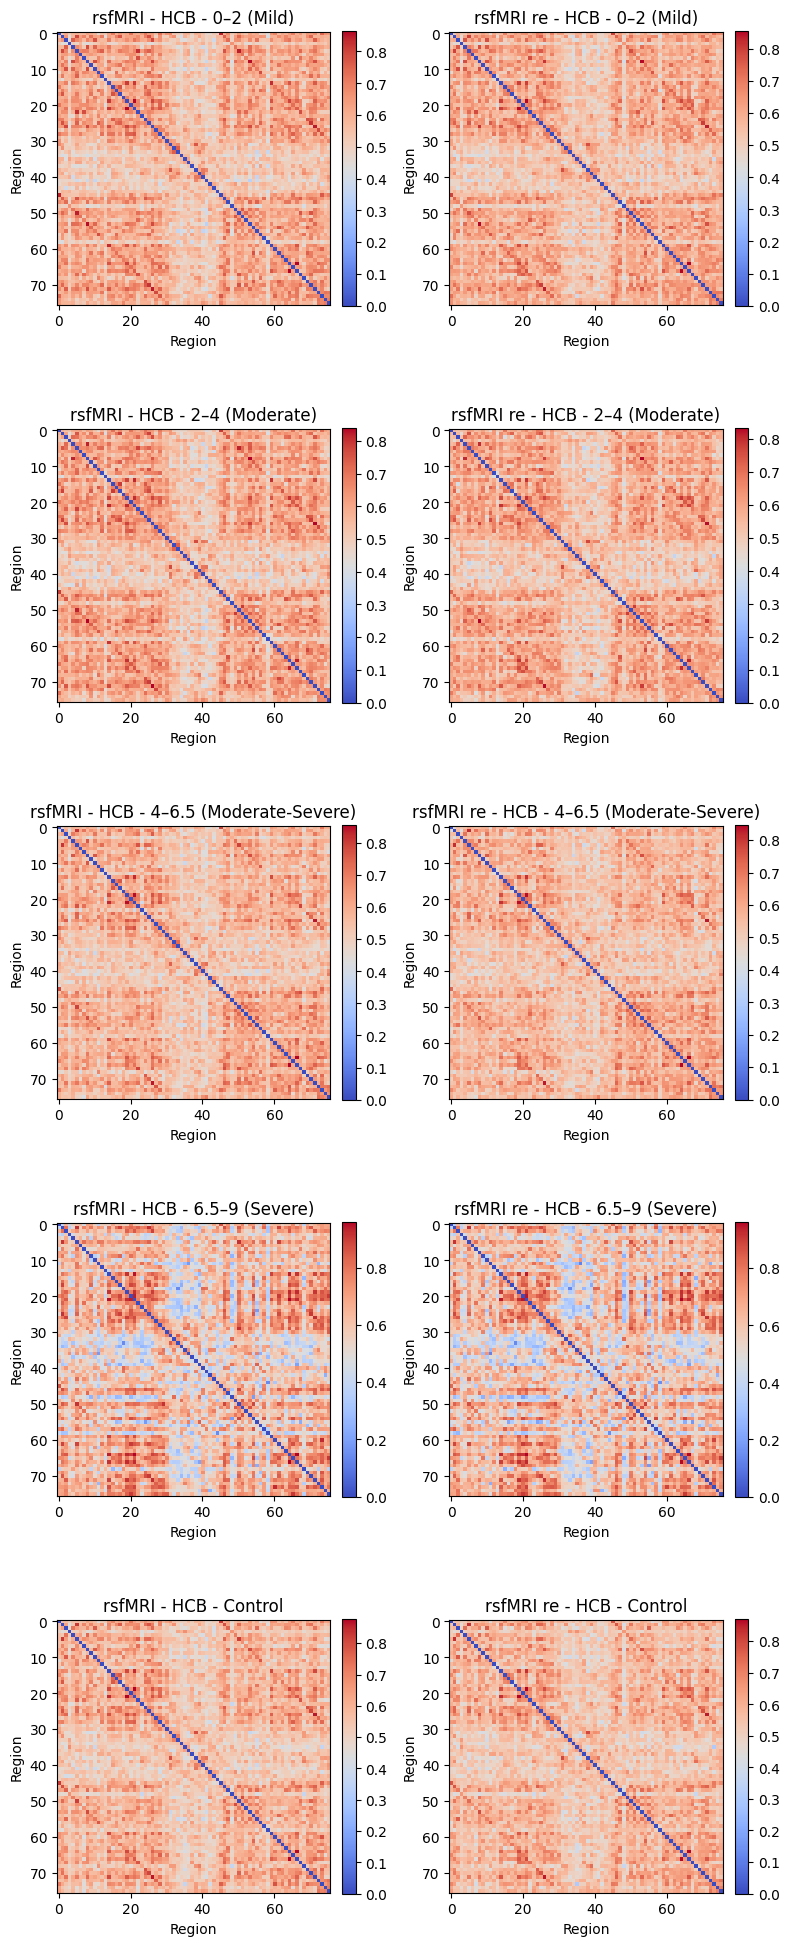

In [34]:
plot_multiple_group_mean_matrices(
    matrix_dicts=[
        mean_matrices_edss,        
        mean_matrices_edss_re
    ],
    titles=[
        "rsfMRI - HCB",
        "rsfMRI re - HCB"
    ],

)

## Save Subject Groupings and Summary Statistics

This section saves relevant summary information per disease duration group (`dd_grp`) to rsfmricilitate downstream analysis, documentation, or external use.

### Outputs:
1. **Subject Group Assignment CSV**  
   - Lists all patient IDs alongside their assigned disease duration group.
   - Format: one row per subject with columns: `dd_group`, `subject_id`.

2. **Group-Level Summary Statistics**  
   - Descriptive statistics (`mean`, `std`, `min`, `max`, etc.) for key clinical variables:
     - `age`, `sex`, `edss`, and `dd`
   - Computed separately per `dd_grp` group.
   - Saved as a multi-index CSV file.

**Example Code:**
```python
df_ids_by_duration.to_csv("output/ids_by_duration_ids.csv", index=False)
group_summary.to_csv("output/ids_by_duration_group_summary.csv")


In [35]:
# === 11. Save summary ===
# Group by dd_grp and collect subject IDs
ids_by_duration = patients.groupby('dd_grp').apply(lambda df: list(df.index))

# Convert to DataFrame (each row = one ID, with its group)
df_ids_by_duration = ids_by_duration.explode().reset_index()
df_ids_by_duration.columns = ['dd_group', 'subject_id']

# Save to CSV
df_ids_by_duration.to_csv(
    "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/output/rsfMRI_ids_by_duration_ids.csv",
    index=False
)

print("✅ Subject IDs per duration group saved successfully.")

# Grouped summary statistics per disease duration group
group_summary = patients.groupby('dd_grp')[['age', 'sex', 'edss', 'dd']].describe()

# Export the full multi-level summary to CSV
group_summary.to_csv(
    "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/output/rsfMRI_ids_by_duration_group_summary.csv"
)

print("✅ Group summary statistics saved successfully.")


✅ Subject IDs per duration group saved successfully.
✅ Group summary statistics saved successfully.


C:\Users\alvar\AppData\Local\Temp\ipykernel_12212\908949057.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ids_by_duration = patients.groupby('dd_grp').apply(lambda df: list(df.index))
C:\Users\alvar\AppData\Local\Temp\ipykernel_12212\908949057.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ids_by_duration = patients.groupby('dd_grp').apply(lambda df: list(df.index))
C:\Users\alvar\AppData\Local\Temp\ipykernel_12212\908949057.py:18: FutureWarning: The default of observed=False is deprecated and wil

## Statistical Analysis Between Groups (Shapiro-Wilk, t-test, Mann-Whitney, Bonferroni)

This step performs a connection-wise statistical comparison between control and MS patient groups using the vectorized FA connectivity data. Each connection (i.e., each column in the DataFrame) is tested for significant group differences.

### Procedure:

1. **Group Labels:**
   - Subjects are labeled as `0` (Control) or `1` (MS Patient) using the `clinic_df['controls_ms']` column.

2. **Loop Over Connections:**
   - For each connection:
     - Extract values for controls and patients.
     - Test for normality in each group using **Shapiro-Wilk**.
     - If both groups are normally distributed:
       - Use **independent t-test**.
     - Otherwise:
       - Use **Mann–Whitney U test** (non-parametric).

3. **Multiple Testing Correction:**
   - Raw *p*-values are corrected using **fdr_bh correction** (`alpha = 0.05`).

4. **Output:**
   - `FA_significant_connections.xlsx`: Only significant connections.
   - `FA_significant_padded_connections.xlsx`: Full matrix, with non-significant connections set to 0.

### Example Summary:
```python
p_values_clean = ...  # Raw p-values
reject, pvals_corrected = multipletests(p_values_clean, method="bonferroni")
significant_connections = p_values_clean.index[reject]

In [36]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# -------------------------
# Input data
# -------------------------
df_corrected = rsfmri_vectors_combat_masked_re.copy()  # DataFrame with FA vectors per subject (163 x 2850)

# Align clinic_df to df_corrected subjects
#clinic_df = clinic_df.set_index("id")
clinic_aligned = clinic_df.loc[df_corrected.index]

# Extract group labels (0 = Control, 1 = MS)
group_labels = clinic_aligned["controls_ms"]

# -------------------------
# Initialize containers
# -------------------------
p_values = []
used_test = []

# -------------------------
# Loop through each connection
# -------------------------
for col in df_corrected.columns:
    control_values = df_corrected[group_labels == 0][col].dropna()
    patient_values = df_corrected[group_labels == 1][col].dropna()

    # Perform test only if both groups have at least 3 samples
    if len(control_values) >= 3 and len(patient_values) >= 3:
        # Shapiro-Wilk test for normality (α = 0.05)
        p_norm_control = shapiro(control_values)[1]
        p_norm_patient = shapiro(patient_values)[1]

        if p_norm_control > 0.05 and p_norm_patient > 0.05:
            # Both distributions are normal → use t-test
            p_val = ttest_ind(control_values, patient_values, equal_var=False)[1]
            used_test.append("t-test")
        else:
            # Non-normal distribution → use Mann-Whitney U test
            p_val = mannwhitneyu(control_values, patient_values, alternative='two-sided')[1]
            used_test.append("mannwhitney")
    else:
        p_val = np.nan
        used_test.append("insufficient")

    p_values.append(p_val)

# -------------------------
# Convert p-values to Series and apply Bonferroni correction
# -------------------------
p_values_series = pd.Series(p_values, index=df_corrected.columns)
used_test = pd.Series(used_test, index=df_corrected.columns)
p_values_clean = p_values_series.dropna()

# Bonferroni correction (α = 0.05)
reject, pvals_corrected, _, _ = multipletests(p_values_clean, alpha=0.05, method='bonferroni')

# -------------------------
# Extract significant connections
# -------------------------
significant_connections = p_values_clean.index[reject]
print(f"✅ Significant connections after Bonferroni: {len(significant_connections)}")

# -------------------------
# VERSION 1: Only significant connections
# -------------------------
significant_df = df_corrected[significant_connections]
significant_df.to_excel("F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/output/rsfmri_significant_connections.xlsx", index=True)

# -------------------------
# VERSION 2: Full matrix with non-significant connections set to 0
# -------------------------
significant_padded_df = pd.DataFrame(0.0, index=df_corrected.index, columns=df_corrected.columns)
significant_padded_df.loc[:, significant_connections] = df_corrected[significant_connections]
significant_padded_df.to_excel("F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/output/rsfmri_significant_padded_connections.xlsx", index=True)

# -------------------------
# Summary statistics for all 2850 connections
# -------------------------
stats_summary = pd.DataFrame({
    "p_raw": p_values_series,
    "test": used_test
})
stats_summary["p_corrected"] = np.nan
stats_summary.loc[p_values_clean.index, "p_corrected"] = pvals_corrected
stats_summary["significant"] = False
stats_summary.loc[significant_connections, "significant"] = True

stats_summary.to_excel(
    "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/output/rsfmri_significant_stats_summary.xlsx"
)

# -------------------------
# Preview results (optional)
# -------------------------
print("\n🔍 Preview of significant connections:")
display(significant_df.head())

print("\n🔍 Preview of padded matrix (non-significant = 0):")
display(significant_padded_df.head())

print("\n📊 Summary of all 2850 connections saved to: rsfmri_significant_stats_summary.xlsx")

✅ Significant connections after Bonferroni: 0

🔍 Preview of significant connections:


""
002MSVIS
003MSVIS
004MSVIS
005MSVIS
010MSVIS



🔍 Preview of padded matrix (non-significant = 0):


,0,1,2,3,4,5,6,7,8,9,...,2840,2841,2842,2843,2844,2845,2846,2847,2848,2849
002MSVIS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
003MSVIS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
004MSVIS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
005MSVIS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
010MSVIS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



📊 Summary of all 2850 connections saved to: rsfmri_significant_stats_summary.xlsx
